In [1]:
import polars as pl

from lzipp_ml_lib.analysis import plotting, summarize

path = "../data/btc.csv"
df = pl.read_csv(path, infer_schema_length=None).with_columns(
    pl.col("date").str.to_datetime(r"%m/%d/%Y %H:%M")
)
df.describe()

/Users/leon/Desktop/programming/ml-training/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


statistic,date,btc_market_price,btc_total_bitcoins,btc_market_cap,btc_trade_volume,btc_blocks_size,btc_avg_block_size,btc_n_orphaned_blocks,btc_n_transactions_per_block,btc_median_confirmation_time,btc_hash_rate,btc_difficulty,btc_miners_revenue,btc_transaction_fees,btc_cost_per_transaction_percent,btc_cost_per_transaction,btc_n_unique_addresses,btc_n_transactions,btc_n_transactions_total,btc_n_transactions_excluding_popular,btc_n_transactions_excluding_chains_longer_than_100,btc_output_volume,btc_estimated_transaction_volume,btc_estimated_transaction_volume_usd
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""2906""",2906.0,2879.0,2906.0,2885.0,2877.0,2906.0,2906.0,2906.0,2894.0,2906.0,2890.0,2906.0,2896.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0
"""null_count""","""0""",0.0,27.0,0.0,21.0,29.0,0.0,0.0,0.0,12.0,0.0,16.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2014-02-08 12:00:00""",839.104218,1.1511e7,1.3443e10,7.3984e7,35505.502848,0.350366,0.364074,671.673651,7.501113,1.2441e6,1.6070e11,2.1844e6,60.434503,66.747821,14.639125,193786.14212,102081.138334,6.8446e7,94348.852374,63140.320028,1.5662e6,203647.468422,2.0243e8
"""std""",null,2304.972497,4.2000e6,3.8661e10,2.9242e8,43618.633821,0.353168,0.842259,689.561322,4.974549,2.9241e6,3.7275e11,5.6699e6,117.737162,1761.894646,20.536083,208914.629495,103896.92935,8.2853e7,103966.111763,69687.052174,2.2789e6,268278.116889,5.8005e8
"""min""","""2010-02-17 00:00:00""",0.0,2.0432e6,0.0,0.0,0.0,0.000216,0.0,1.0,0.0,0.0000225,2.527738,0.0,0.0,0.136531,0.0,110.0,118.0,41240.0,118.0,118.0,6150.0,7.0,0.0
"""25%""","""2012-02-13 00:00:00""",6.65062,8.4886e6,5.362484e7,291645.648,781.0,0.024158,0.0,54.0,6.066667,11.608773,1.5911e6,46552.5692,9.486228,1.181556,4.155851,16750.0,8023.0,2.410949e6,6812.0,6762.0,489722.0732,95988.0,957933.0
"""50%""","""2014-02-09 00:00:00""",235.13,1.243115e7,3.3475e9,1.0014e7,15183.0,0.19619,0.0,375.0,7.916667,21761.8906,2.1938e9,873579.6,20.438063,2.495254,7.82947,130490.0,62354.0,3.2582349e7,53496.0,35308.0,1.1052e6,178482.5592,3.7461945e7
"""75%""","""2016-02-05 00:00:00""",594.274886,1.52025e7,8.0776e9,2.8340e7,58293.0,0.676204,0.0,1233.0,10.216667,1.0366e6,1.1335e11,1.8283e6,49.620778,5.91617,14.804949,360393.0,190528.0,1.08120269e8,185911.0,113794.0,2.0319e6,258845.1805,1.3133e8
"""max""","""2018-01-31 00:00:00""",19498.68333,1.6838e7,3.2652e11,5.3520e9,154444.5903,1.110327,7.0,2722.625,47.733333,2.1610e7,2.6031e12,5.3192e7,1495.946477,88571.42857,161.686071,1.072861e6,490644.0,2.96688784e8,470650.0,318896.0,4.5992e7,5.825066e6,5.7602e9


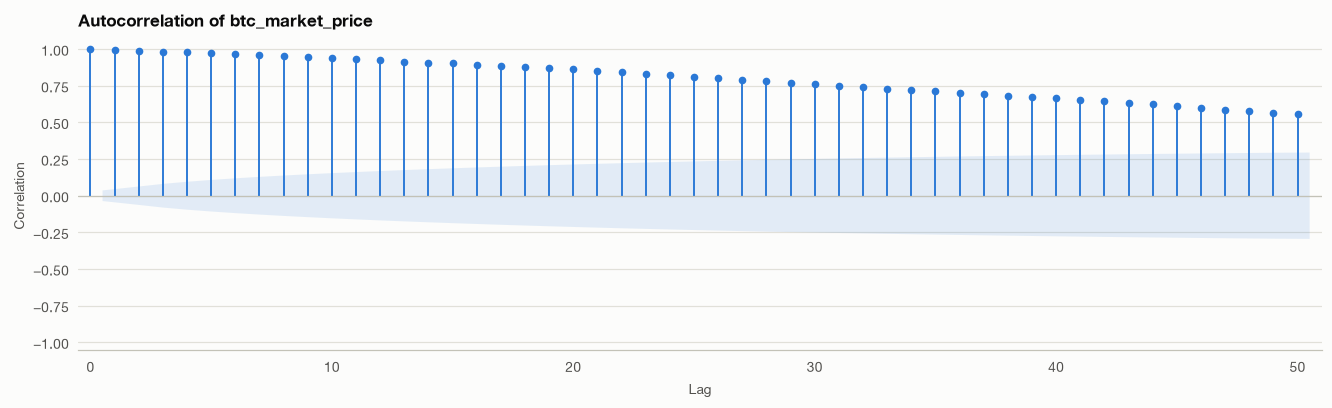

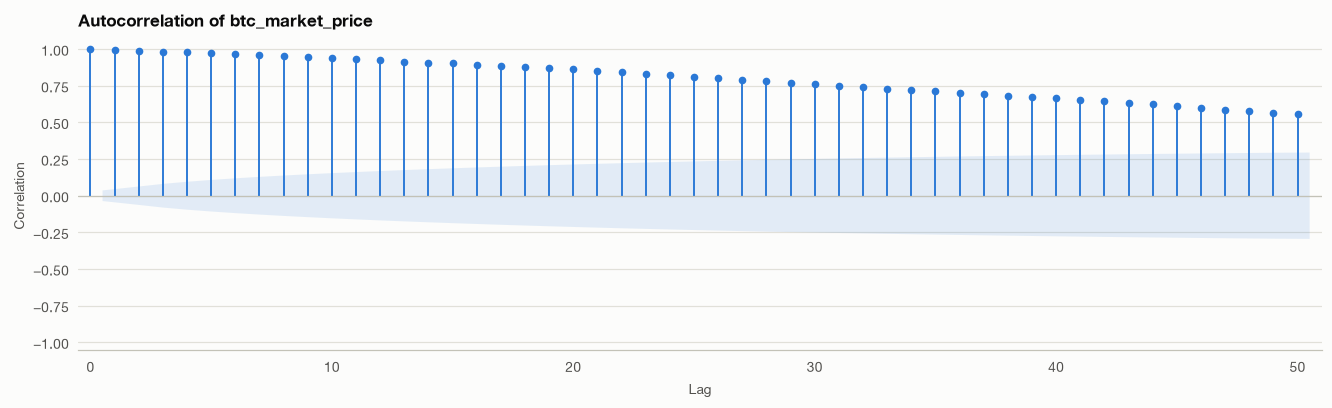

In [2]:
plotting.plot_autocorrelation(df, "btc_market_price")

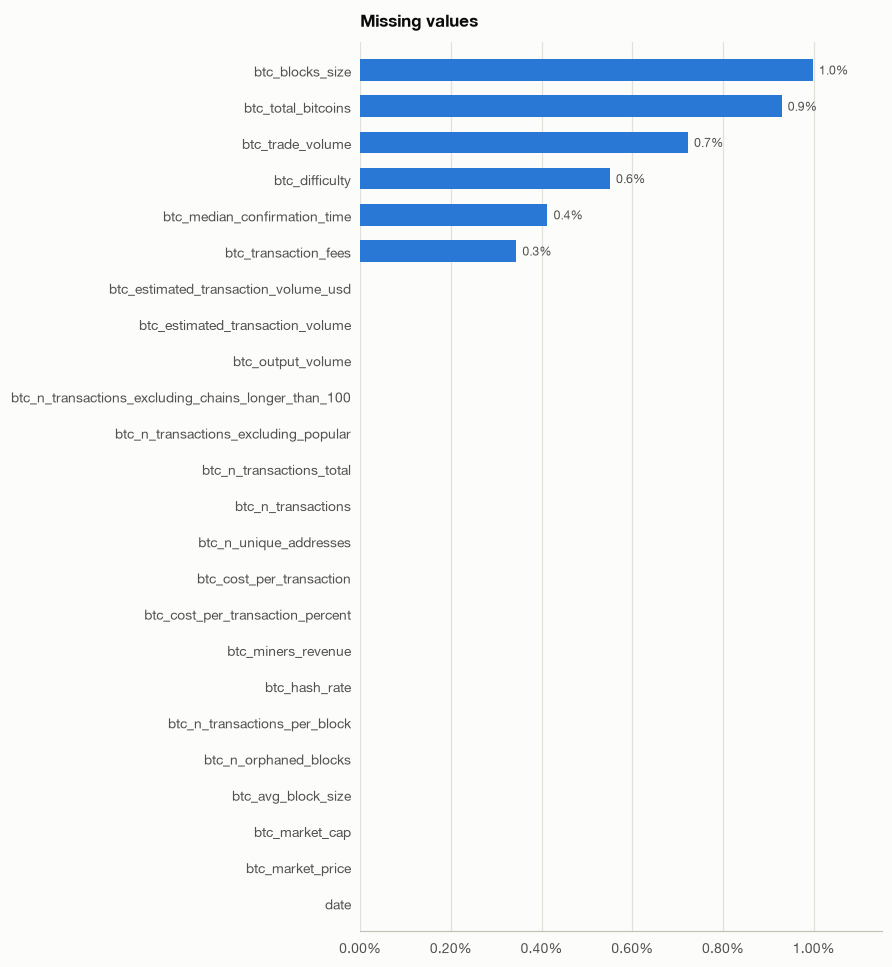

In [3]:
plotting.plot_missing_values(df)

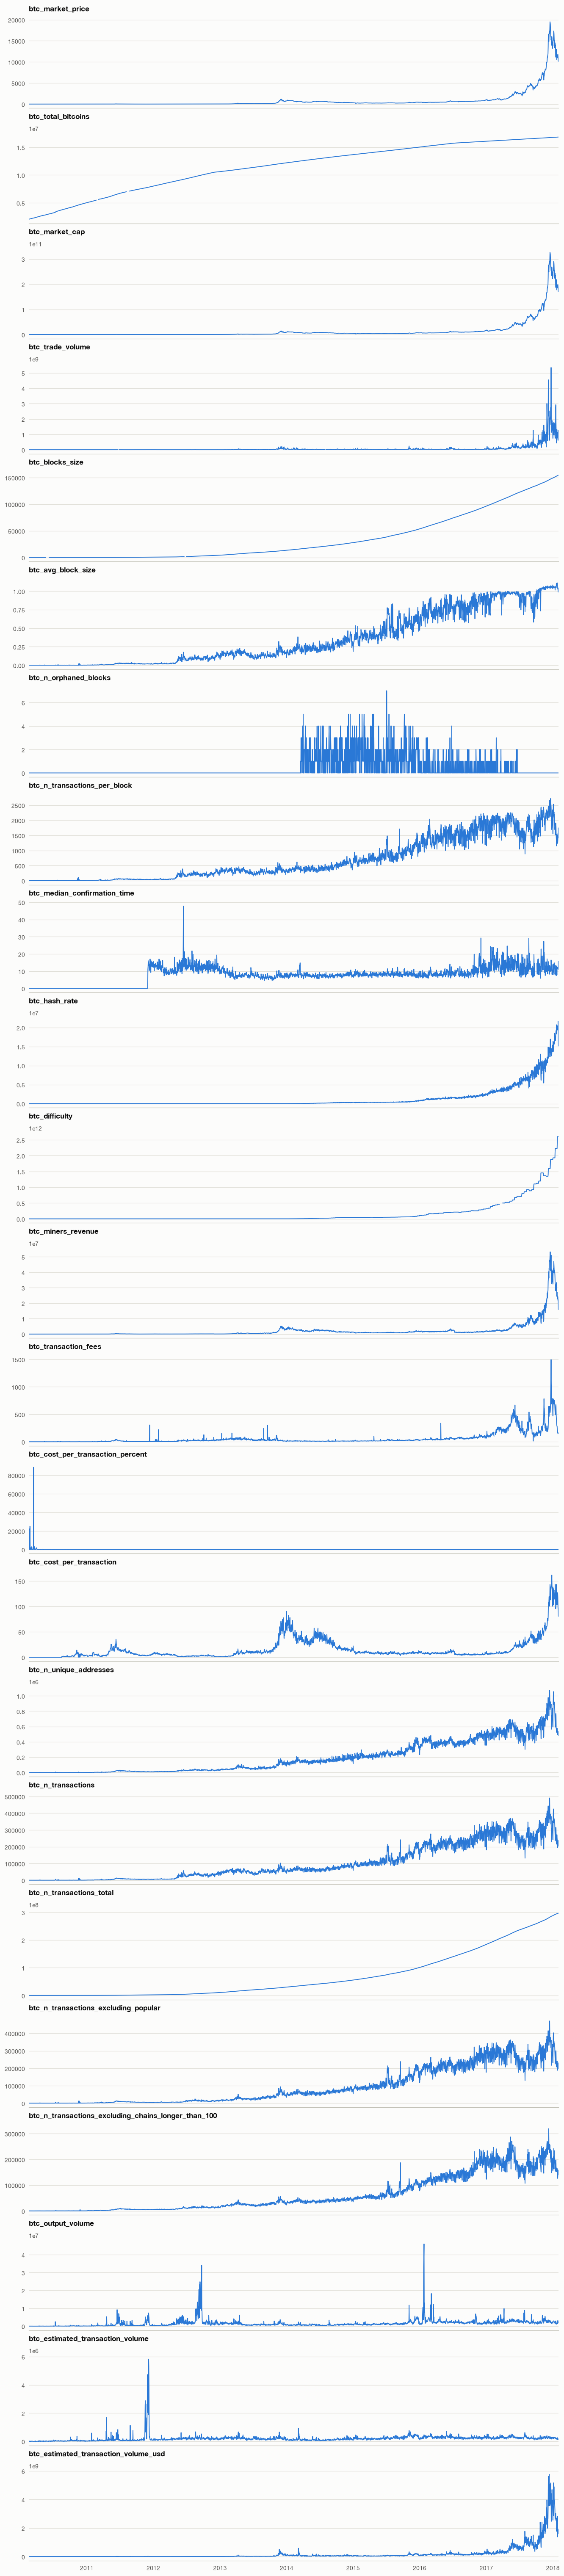

In [4]:
plotting.plot_timeseries_grid(df, "date")

In [5]:
plotting.plot_violinplots(df)

TypeError: Data source must be a DataFrame or Mapping, not <class 'polars.dataframe.frame.DataFrame'>.

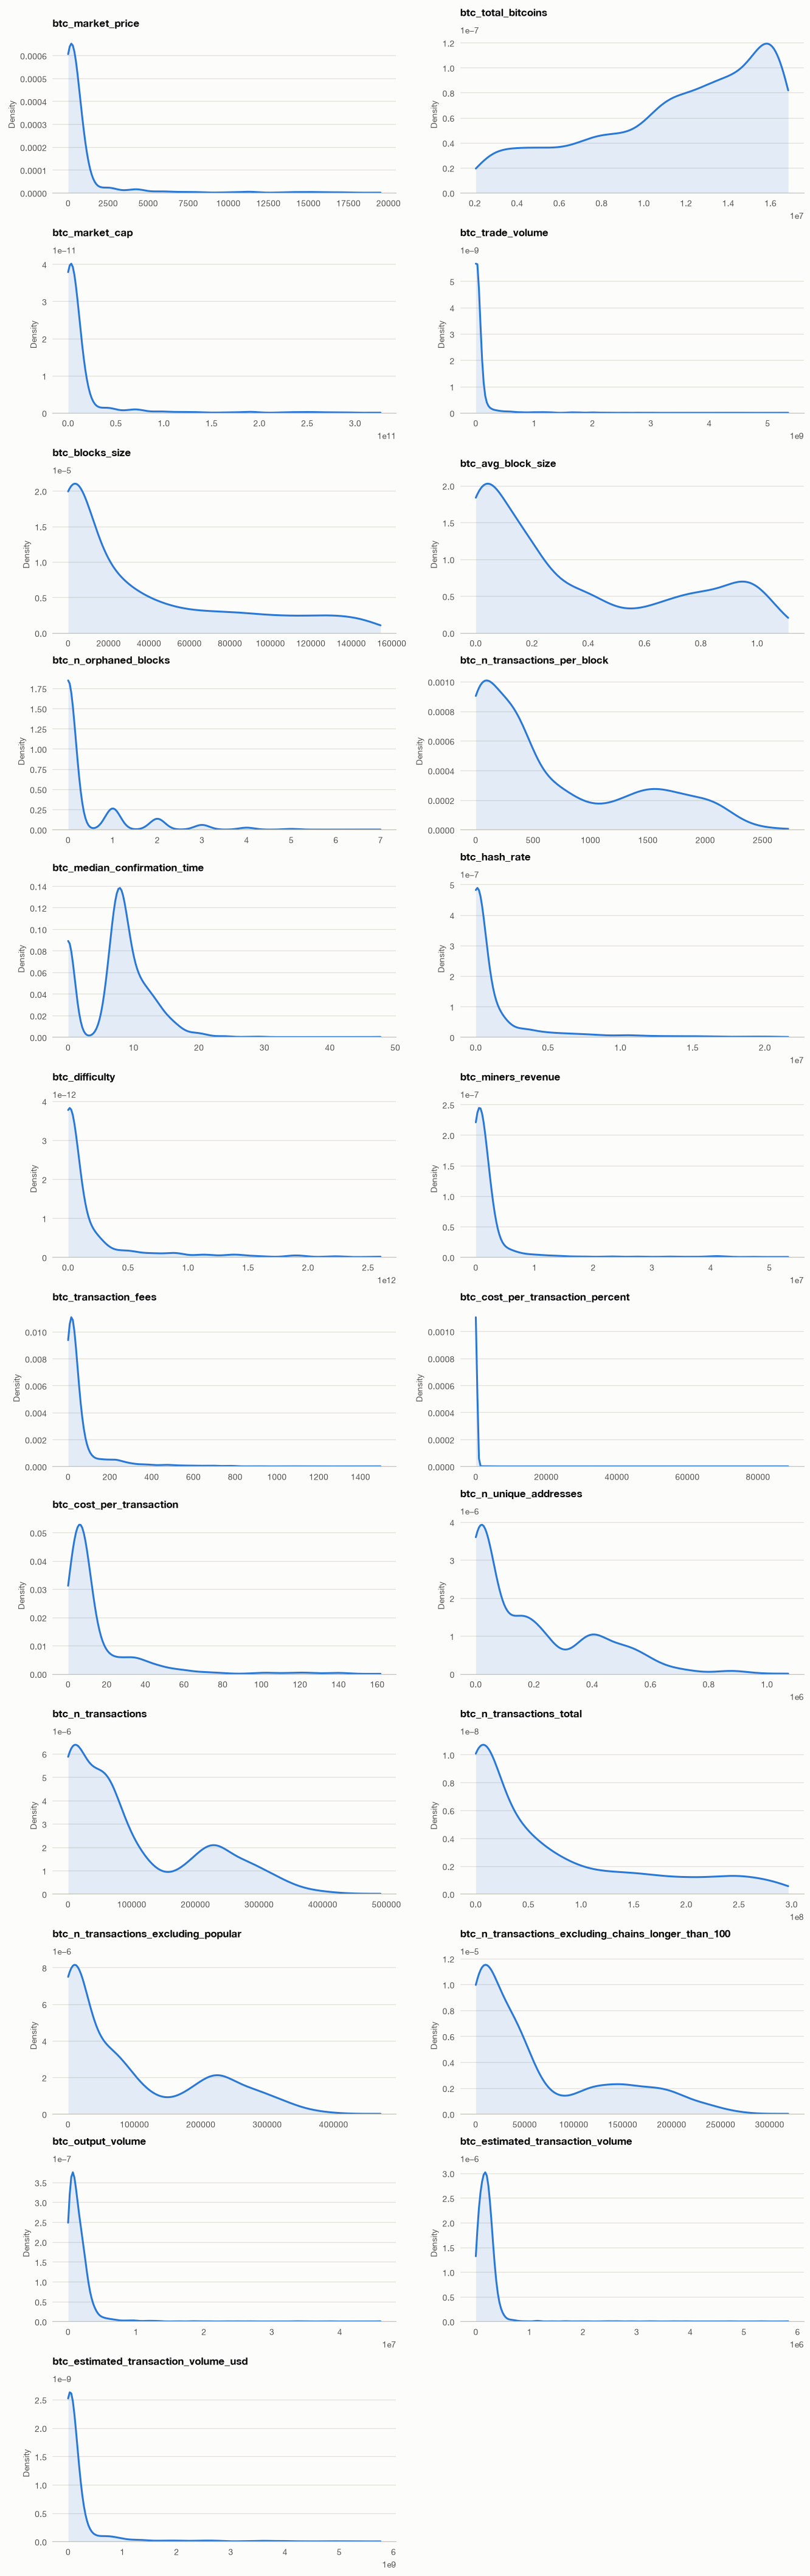

In [ ]:
plotting.plot_kde(df)

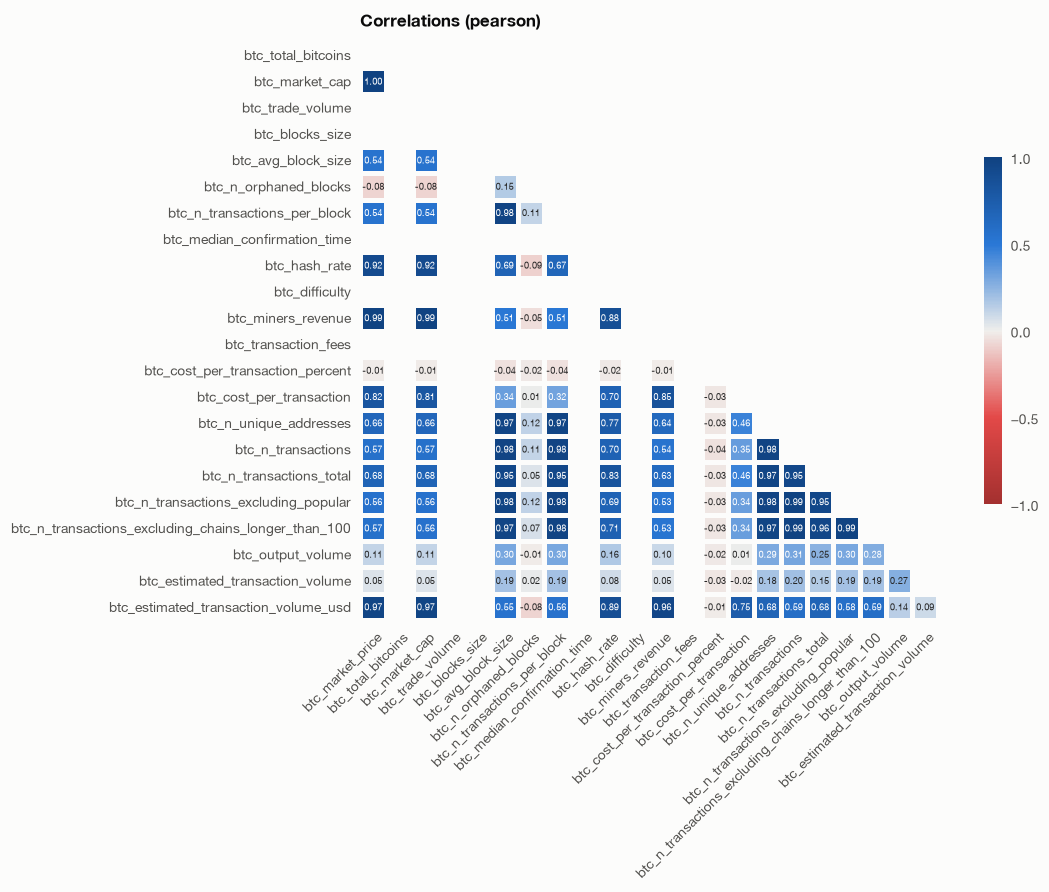

In [ ]:
plotting.plot_corr_heatmap(df)

## Group 1: summary statistics & distributions

`housing.csv` (Boston housing): `medv` is the target. `river` and `rad_cat` are categorical versions of `chas` and `rad`, to have string columns to plot.

In [ ]:
housing = (
    pl.read_csv("../data/housing.csv")
    .drop("id")
    .with_columns(
        river=pl.when(pl.col("chas") == 1)
        .then(pl.lit("on river"))
        .otherwise(pl.lit("inland")),
        rad_cat=pl.col("rad").cast(pl.String),
    )
)
summarize(housing)

column,dtype,count,null_pct,n_unique,mean,std,min,p25,median,p75,max,skew,zeros_pct
str,str,u32,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""crim""","""Float64""",506,0.0,504,3.613524,8.601545,0.00632,0.082045,0.25651,3.6770825,88.9762,5.207652,0.0
"""zn""","""Float64""",506,0.0,26,11.363636,23.322453,0.0,0.0,0.0,12.5,100.0,2.219063,73.517787
"""indus""","""Float64""",506,0.0,76,11.136779,6.860353,0.46,5.19,9.69,18.1,27.74,0.294146,0.0
"""chas""","""Int64""",506,0.0,2,0.06917,0.253994,0.0,0.0,0.0,0.0,1.0,3.395799,93.083004
"""nox""","""Float64""",506,0.0,81,0.554695,0.115878,0.385,0.449,0.538,0.624,0.871,0.727144,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""black""","""Float64""",506,0.0,357,356.674032,91.294864,0.32,375.3775,391.44,396.225,396.9,-2.881798,0.0
"""lstat""","""Float64""",506,0.0,455,12.653063,7.141062,1.73,6.95,11.36,16.955,37.97,0.903771,0.0
"""medv""","""Float64""",506,0.0,229,22.532806,9.197104,5.0,17.025,21.2,25.0,50.0,1.104811,0.0


Histograms show what a KDE smooths away: `zn`'s pile of zeros, `chas` and `rad` as discrete values (one bar each), `medv` capped at 50.

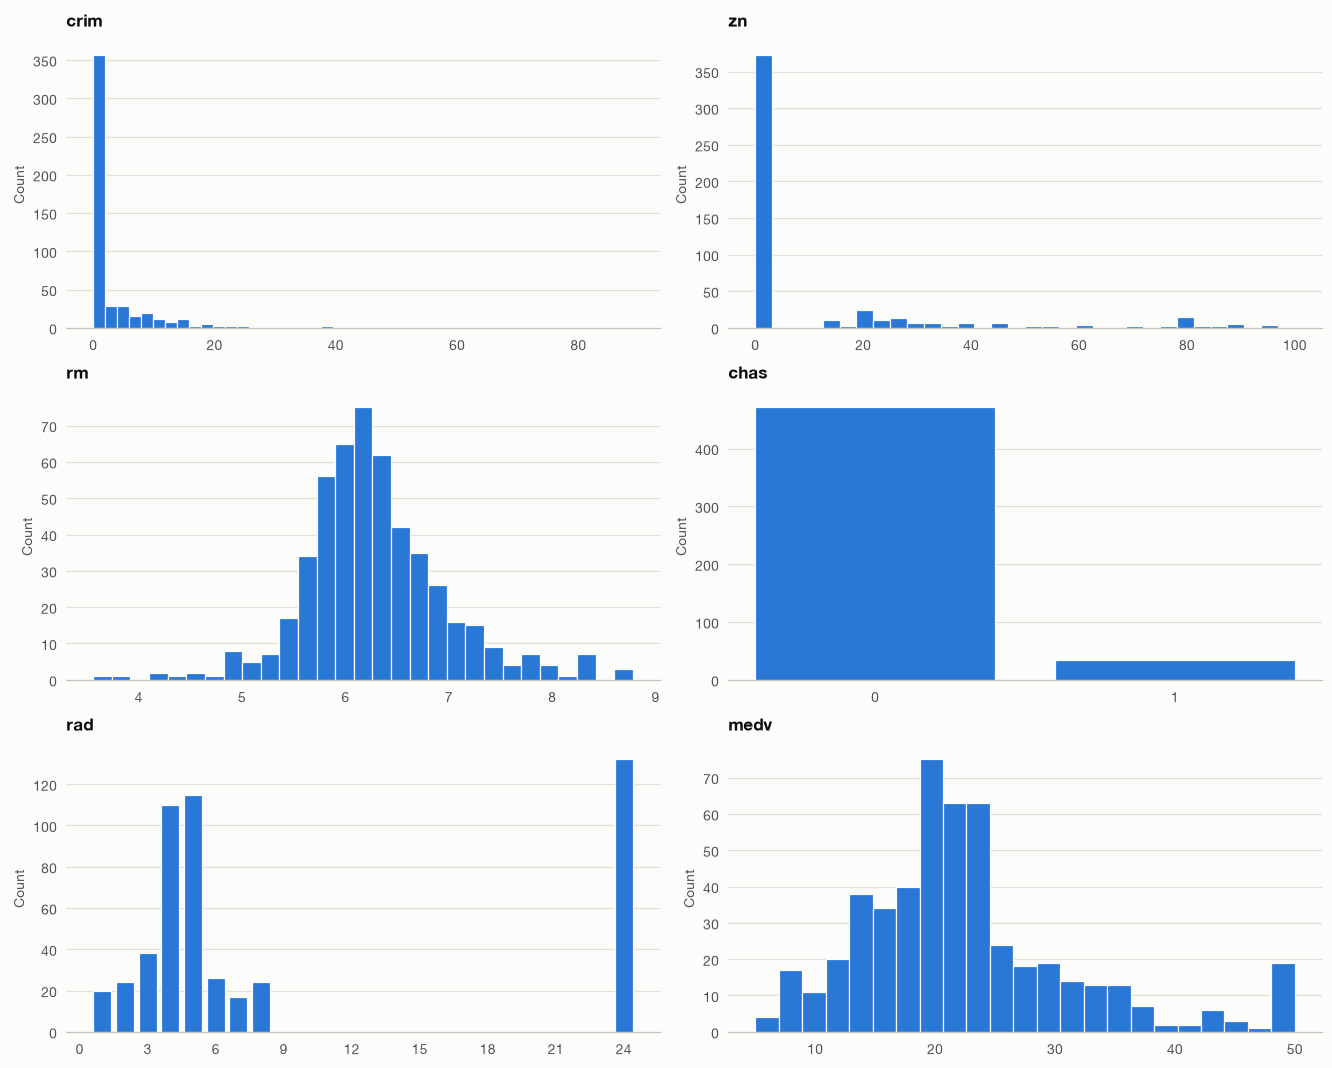

In [ ]:
plotting.plot_histograms(housing, ["crim", "zn", "rm", "chas", "rad", "medv"])

`by=` compares groups within each panel, each normalized on its own. Overlaid plots get one legend; box and violin plots name the groups on the y axis.

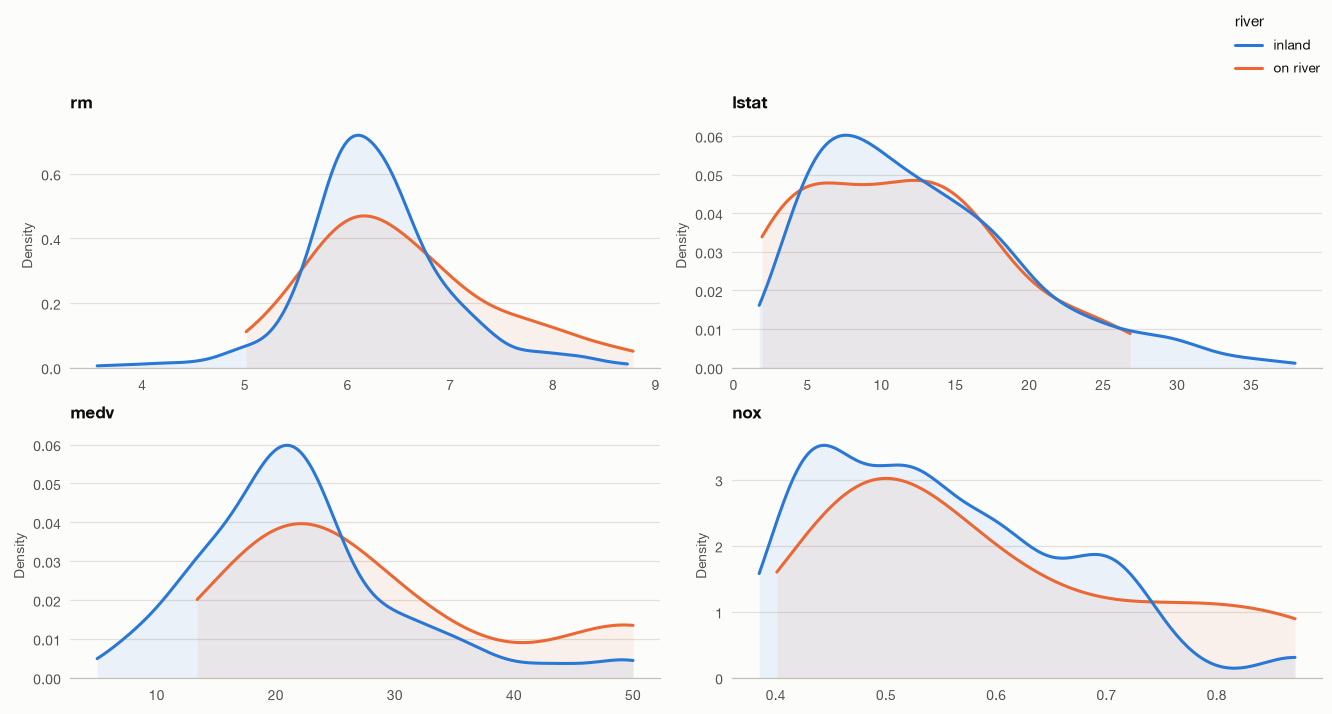

In [ ]:
plotting.plot_kde(housing, ["rm", "lstat", "medv", "nox"], by="river")

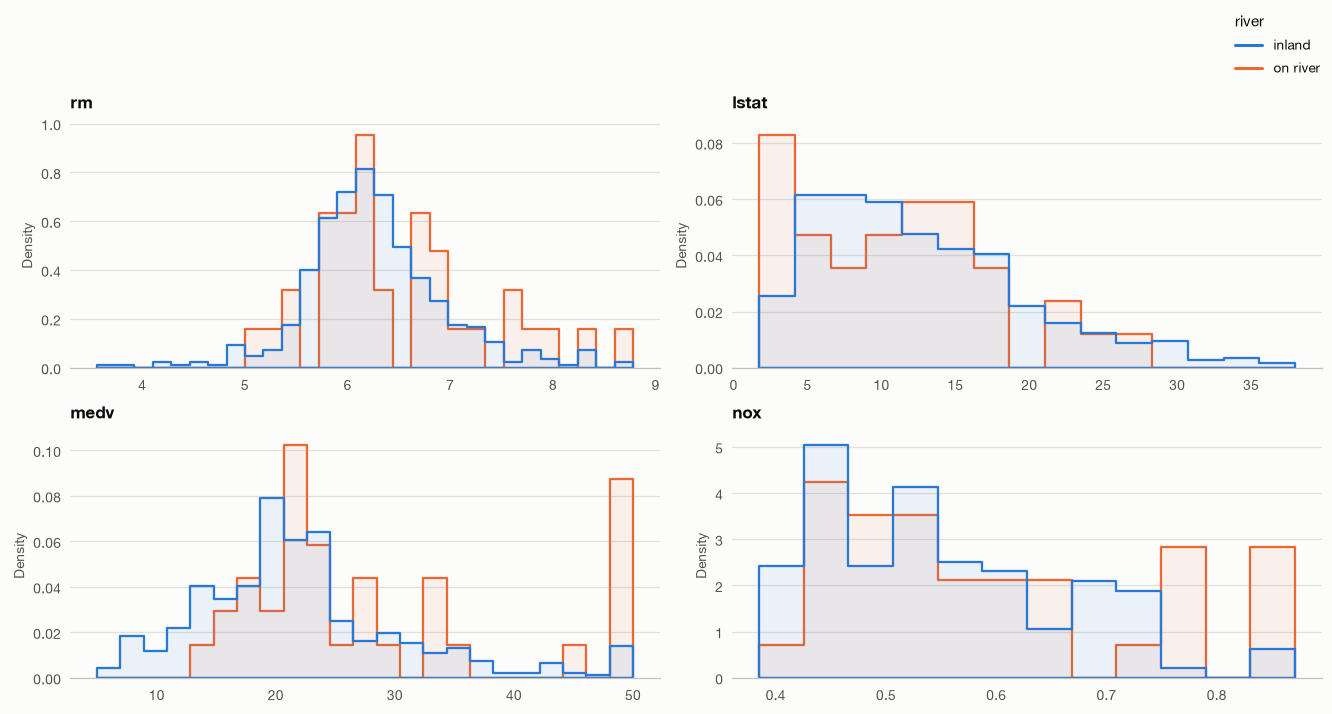

In [ ]:
plotting.plot_histograms(housing, ["rm", "lstat", "medv", "nox"], by="river")

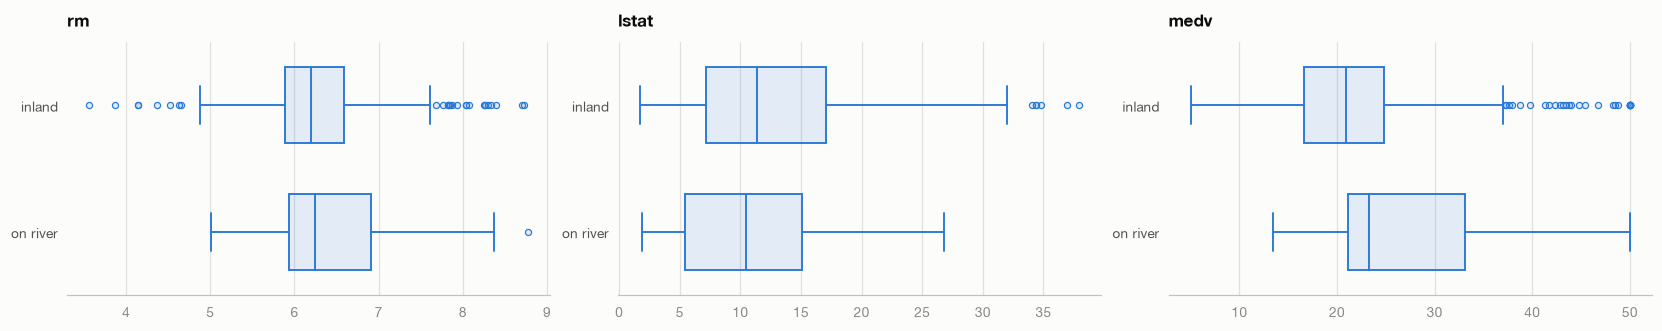

In [ ]:
plotting.plot_boxplots(housing, ["rm", "lstat", "medv"], by="river")

Heavy-tailed data: `log=True` vs. `clip=` (quantile range per column). For exponential growth like BTC, the log scale is the one that helps.

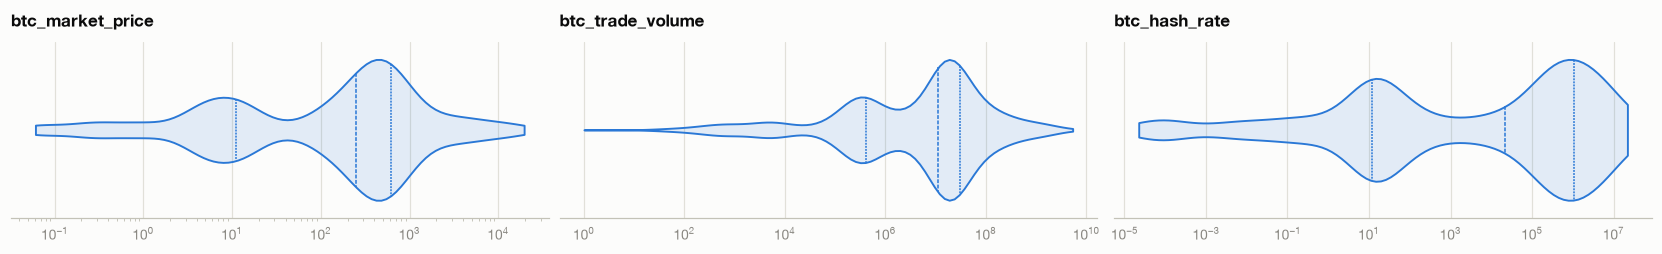

In [ ]:
btc_cols = ["btc_market_price", "btc_trade_volume", "btc_hash_rate"]
plotting.plot_violinplots(df, btc_cols, log=True)

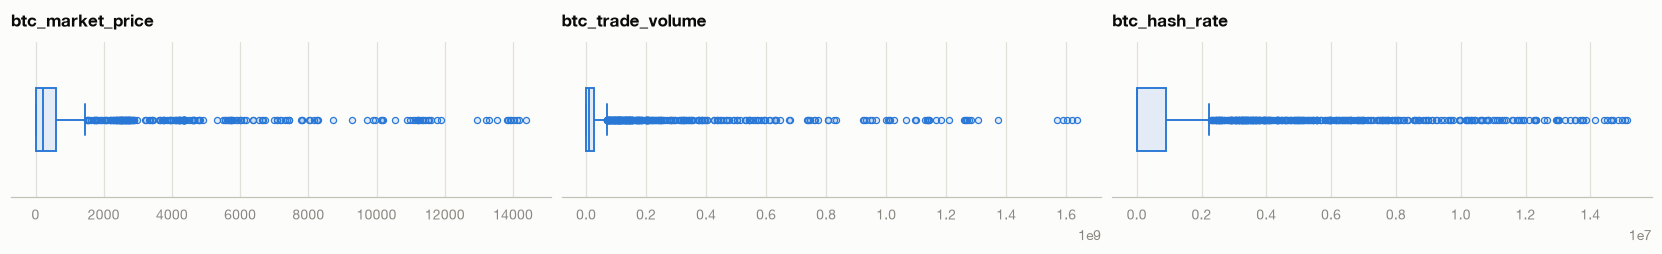

In [ ]:
plotting.plot_boxplots(df, btc_cols, clip=(0.01, 0.99))

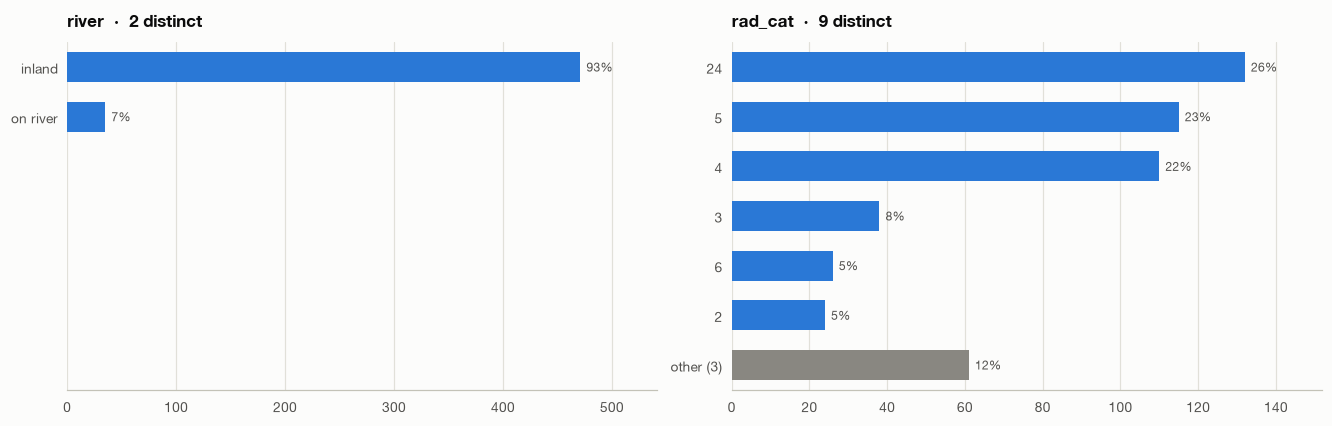

In [ ]:
plotting.plot_category_counts(housing, top_k=6)

Mean target per quantile bin (numeric) or category, with a 95% band; the gray line is the overall mean.

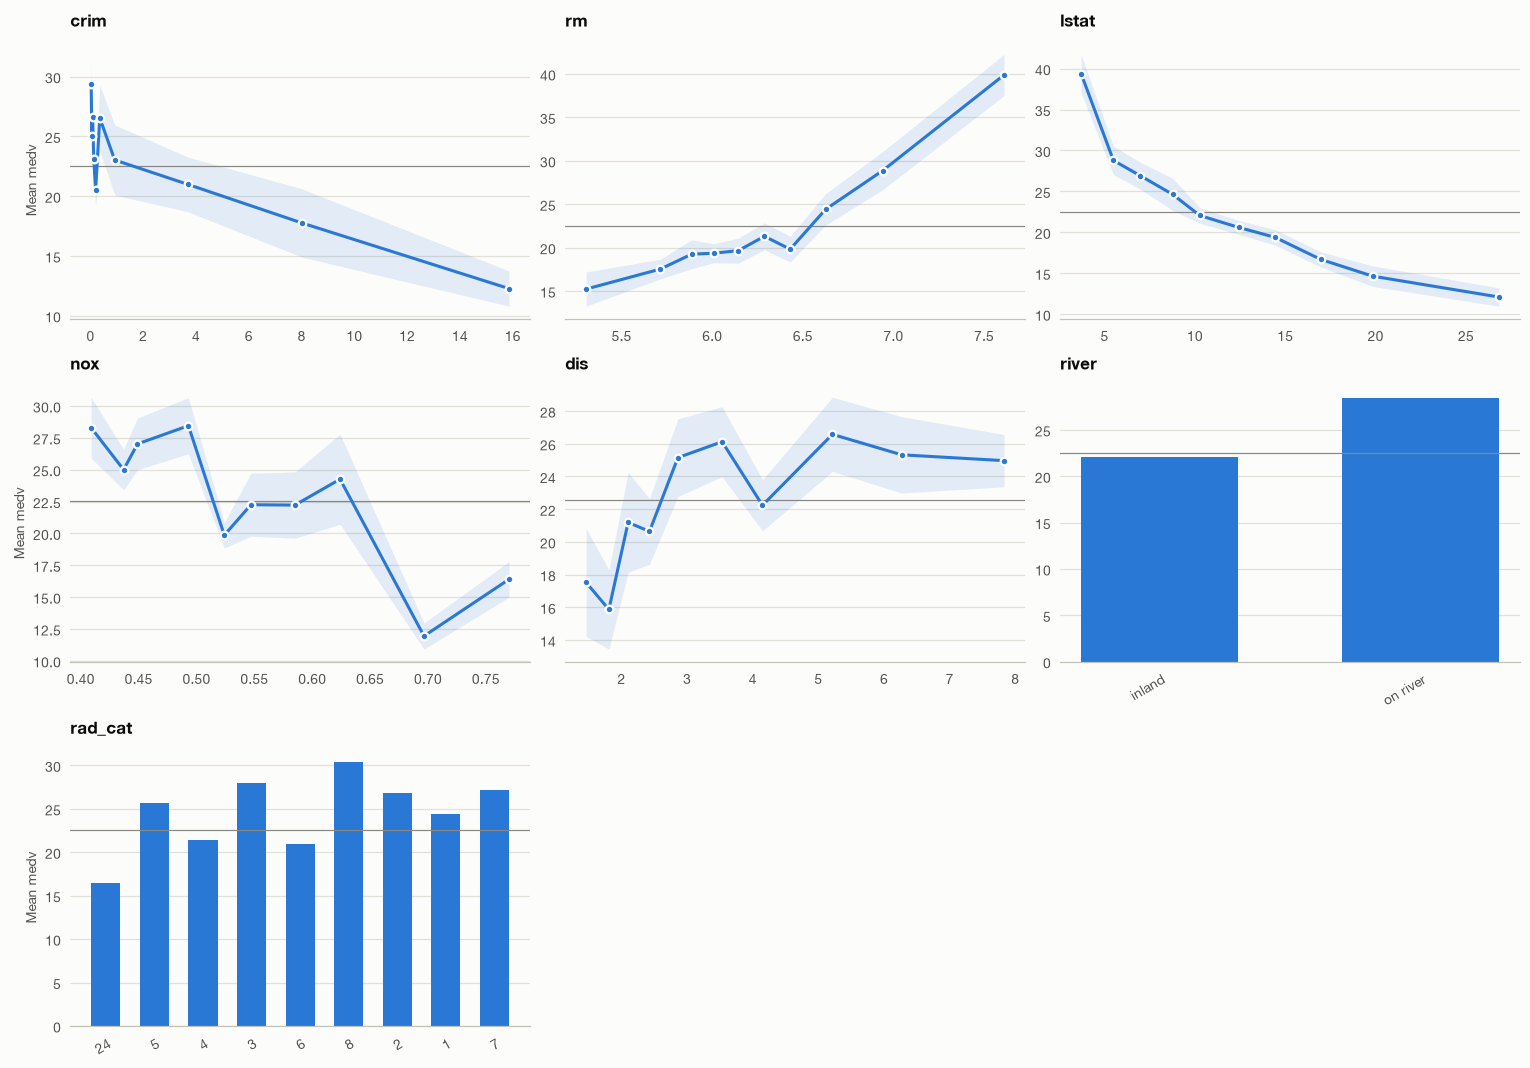

In [ ]:
plotting.plot_feature_target(
    housing, "medv", ["crim", "rm", "lstat", "nox", "dis", "river", "rad_cat"]
)

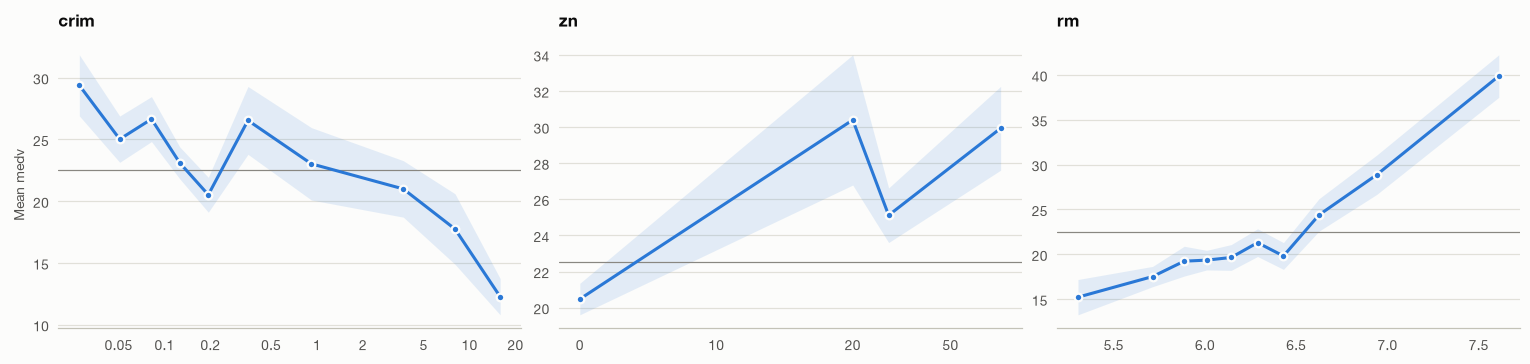

In [ ]:
# skewed features: log x axis; "zn" (73% zeros) gets a symmetric log, so its zeros bin stays
plotting.plot_feature_target(
    housing, "medv", ["crim", "zn", "rm"], log_x=["crim", "zn"]
)

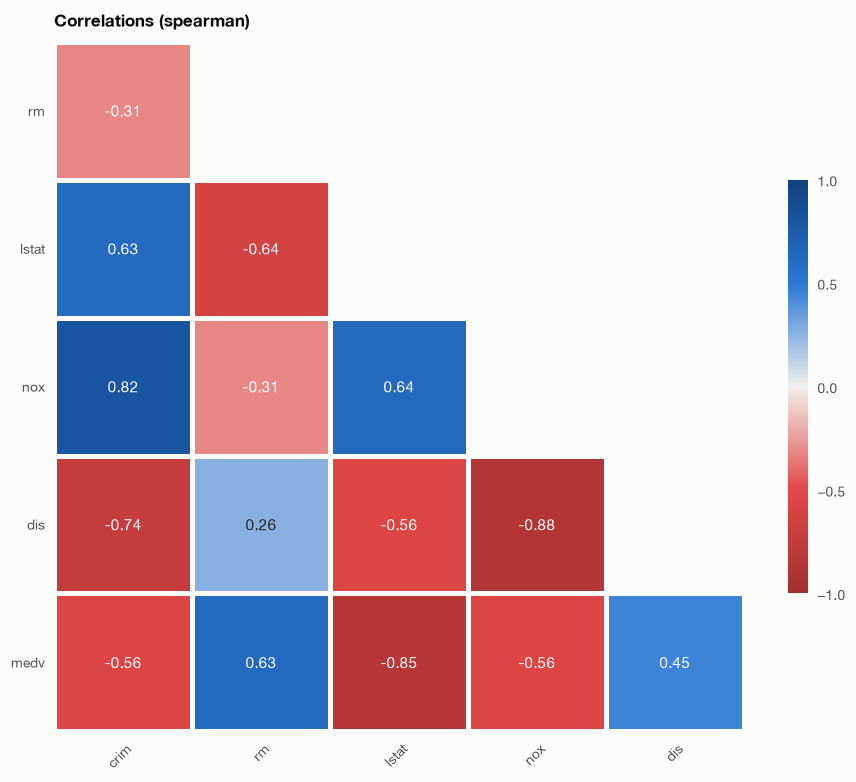

In [ ]:
plotting.plot_corr_heatmap(
    housing, (9, 7), ["crim", "rm", "lstat", "nox", "dis", "medv"], method="spearman"
)

Single-axes plots take `ax=`, so they compose into your own figures.

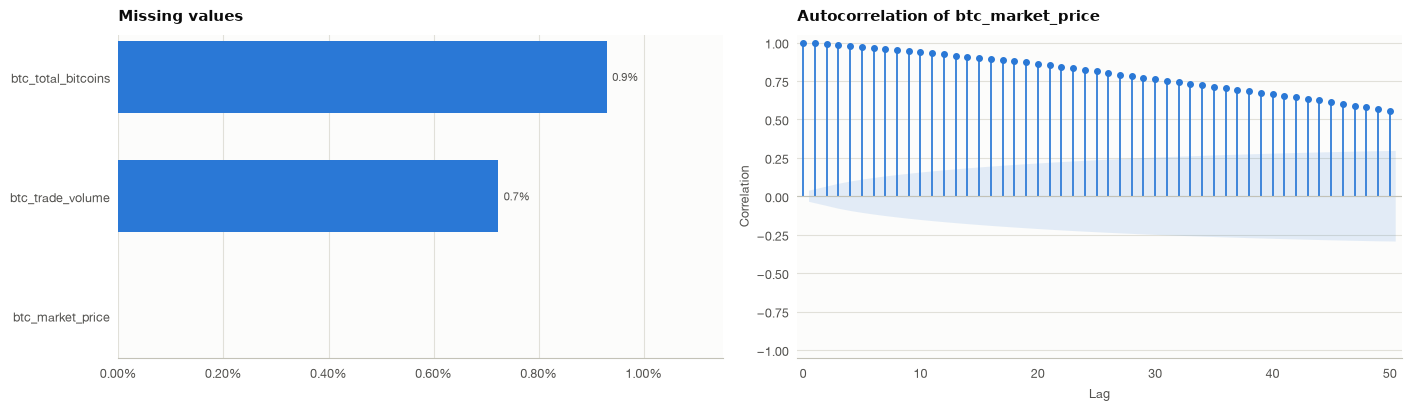

In [ ]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 4), layout="constrained")
plotting.plot_missing_values(
    df, ["btc_market_price", "btc_trade_volume", "btc_total_bitcoins"], ax=left
)
plotting.plot_autocorrelation(df, "btc_market_price", ax=right)

`styled` applies the same look to your own plotting functions.

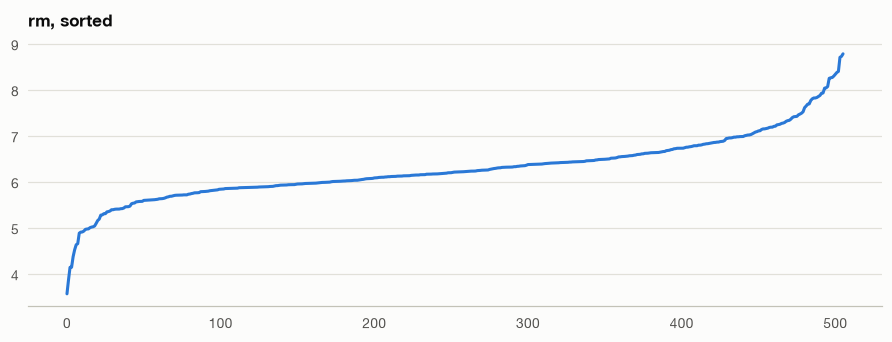

In [ ]:
@plotting.styled
def my_plot():
    fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
    ax.plot(housing["rm"].sort(), color="#2a78d6")
    ax.set_title("rm, sorted")
    return fig


my_plot()

## Group 2: time series

`energy_prices.csv`: hourly, 2004-2018, in the library's `ts` / `val` format. `recent` is the last three months, for the plots where 14 years of hourly points would be one dense block.

In [ ]:
from datetime import datetime

energy = pl.read_csv("../data/energy_prices.csv", try_parse_dates=True)
recent = energy.filter(pl.col("ts") >= datetime(2018, 5, 1))

Gaps: lag features look timestamps up by time, so this is where they come out null. Here: one missing hour every spring (DST) and 4 duplicates (autumn).

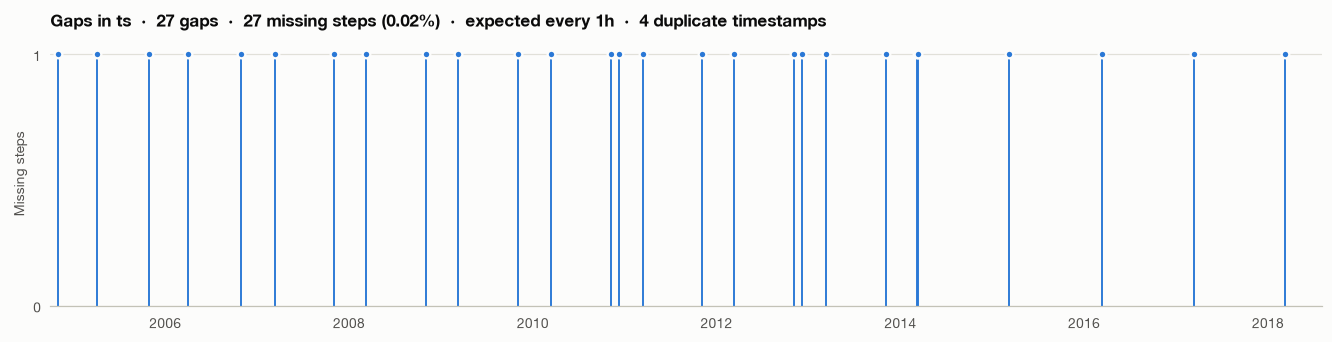

In [ ]:
plotting.plot_gaps(energy)

Calendar profiles: is it worth adding hour / weekday / month features?

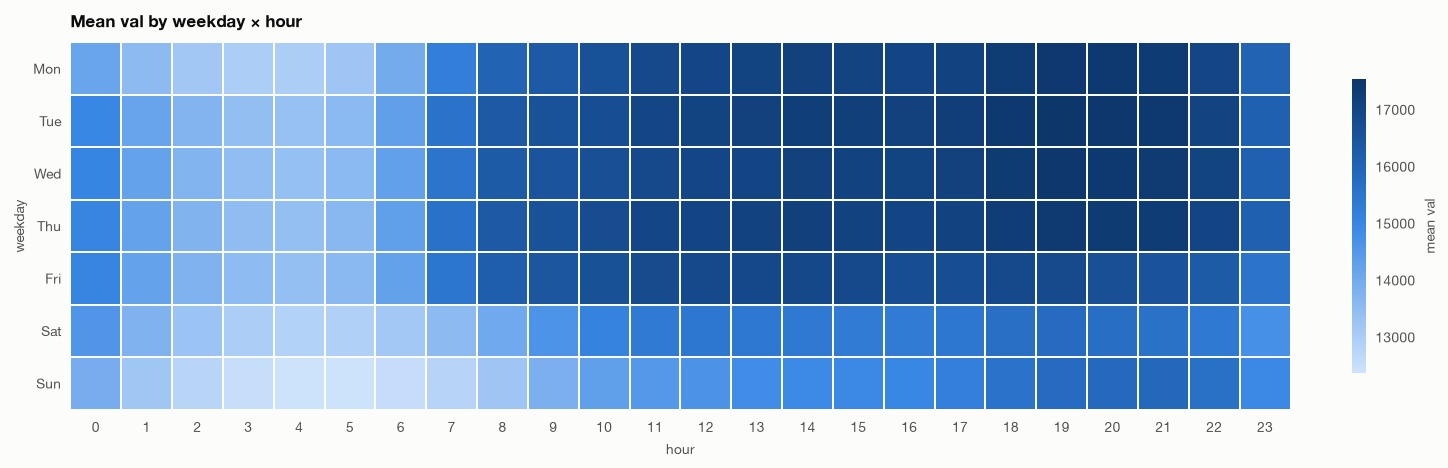

In [ ]:
plotting.plot_seasonal_profile(energy)  # weekday x hour

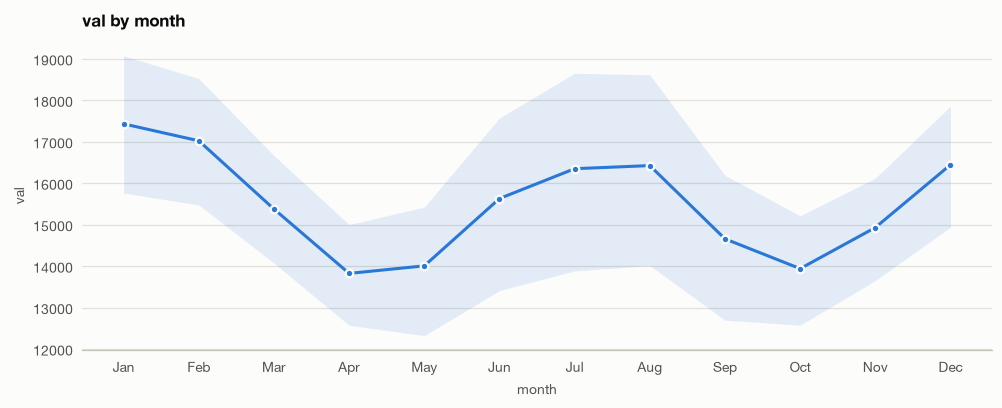

In [ ]:
plotting.plot_seasonal_profile(energy, rows="month", cols=None)

ACF vs. PACF: the ACF shows the daily cycle; the PACF which lags carry signal of their own (1, 2, 24, 25, ...) - candidates for `lag` features.

/var/folders/h6/c2yy64s57ks3xp5rvf8z16t00000gn/T/ipykernel_74293/750914687.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (left, right) = plt.subplots(1, 2, figsize=(14, 3.6), layout="constrained")


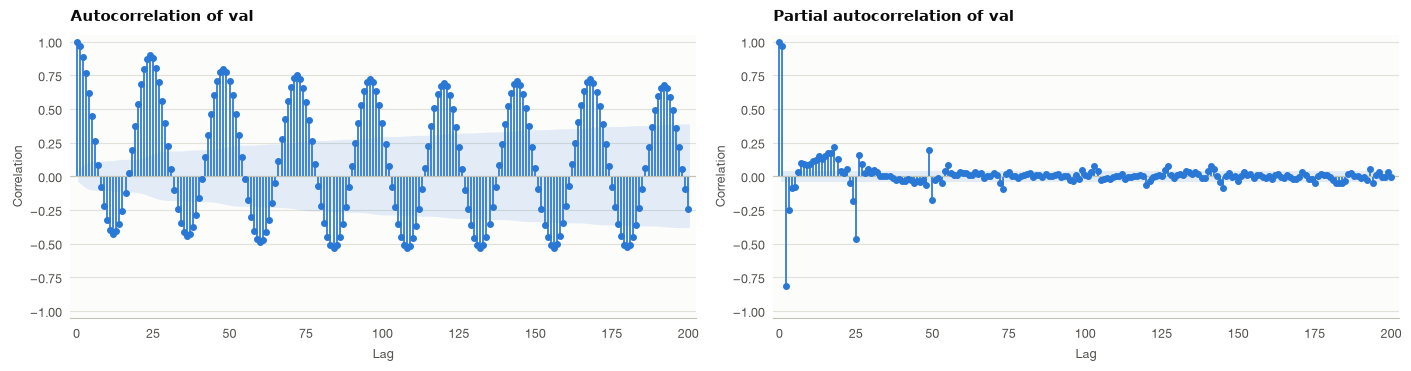

In [ ]:
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 3.6), layout="constrained")
plotting.plot_autocorrelation(recent, "val", lags=200, ax=left)
plotting.plot_partial_autocorrelation(recent, "val", lags=200, ax=right)

Decomposition: a daily and a weekly cycle (MSTL). With one period on the full 14 years, the weekly and yearly cycles end up in the trend.

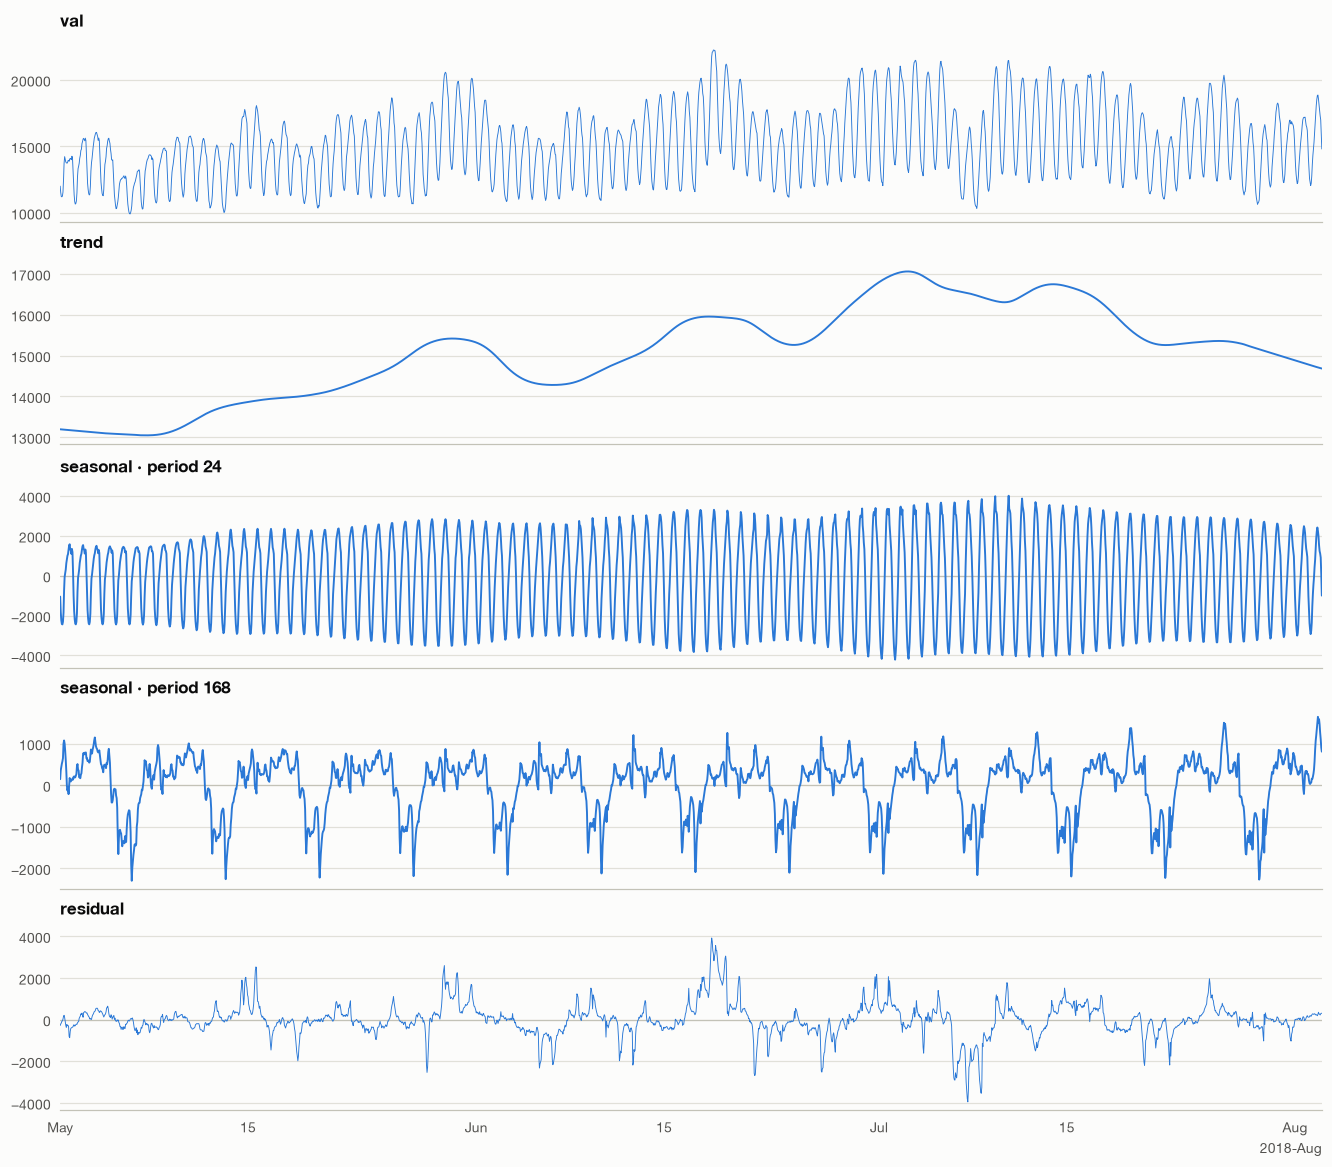

In [ ]:
plotting.plot_decomposition(recent, periods=(24, 168))

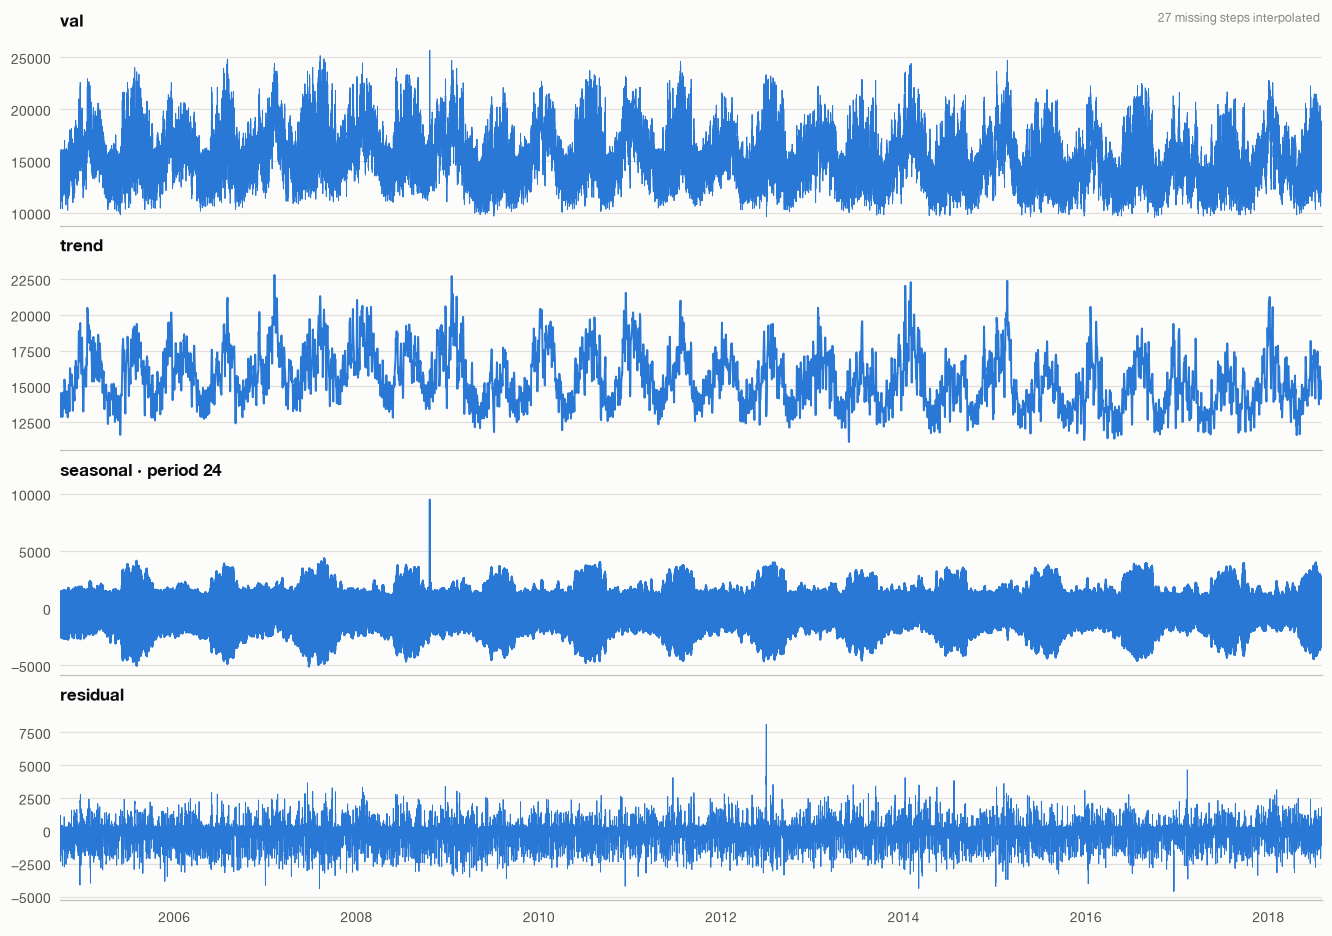

In [ ]:
plotting.plot_decomposition(energy)  # default: one daily period, ~4s

Stationarity: the level and the volatility both follow the seasons; the std is highest in summer and winter.

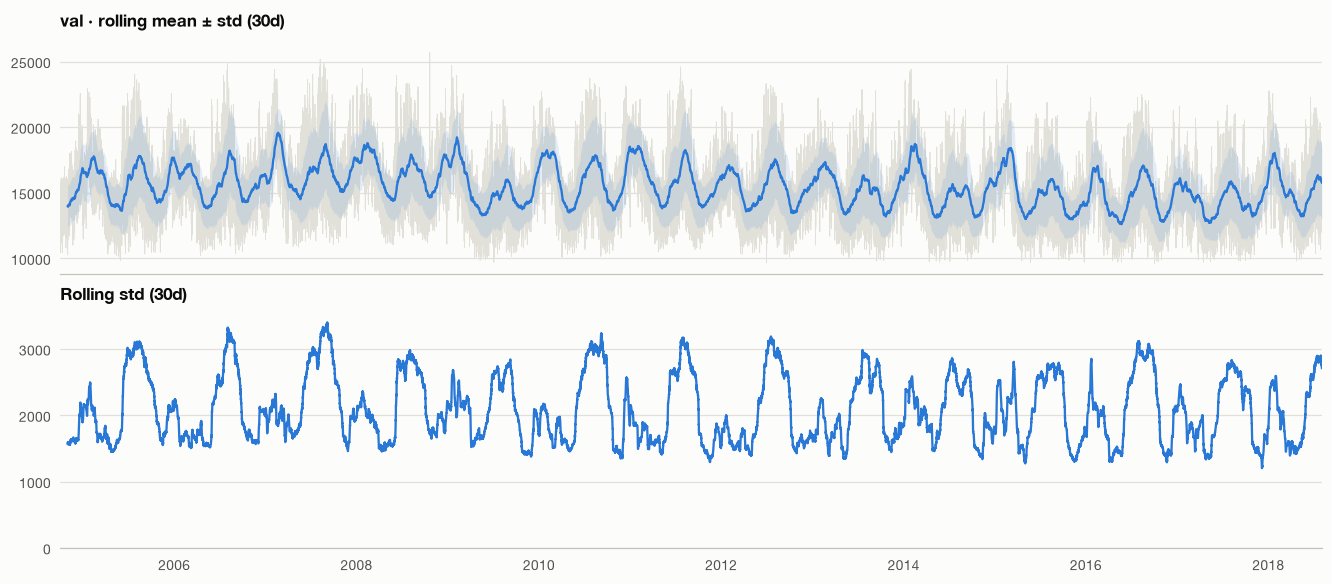

In [ ]:
plotting.plot_rolling_stats(energy, window="30d")

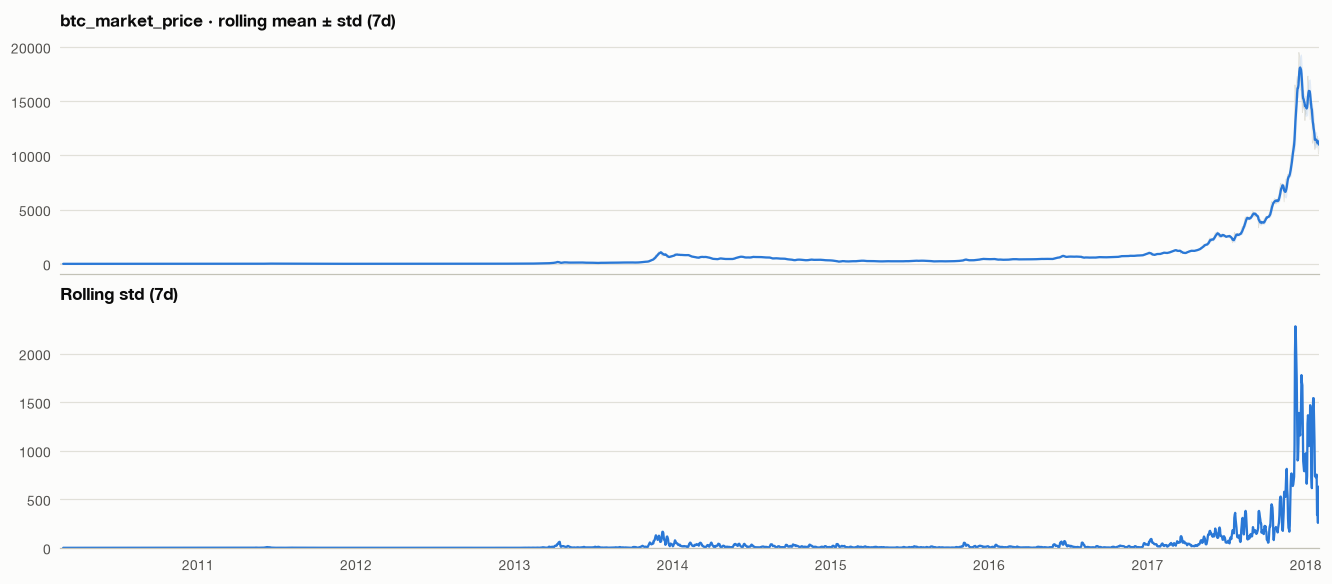

In [ ]:
plotting.plot_rolling_stats(
    df, "date", "btc_market_price"
)  # default window: 7d for daily data

## Group 3: model evaluation

All plots take `y_true` / `y_pred` / `y_proba` as lists, arrays, Series or the single-column `y` frames the `fit_xgb_*` functions use.

### Regression

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

from lzipp_ml_lib.hyperparameter import fit_xgb_classifier, fit_xgb_regressor

h = pl.read_csv("../data/housing.csv").drop("id")
x_train, x_test, y_train, y_test = train_test_split(
    h.drop("medv"), h.select("medv"), test_size=0.25, random_state=0
)
regressor = fit_xgb_regressor(x_train, y_train, x_test, y_test, n_trials=20).model

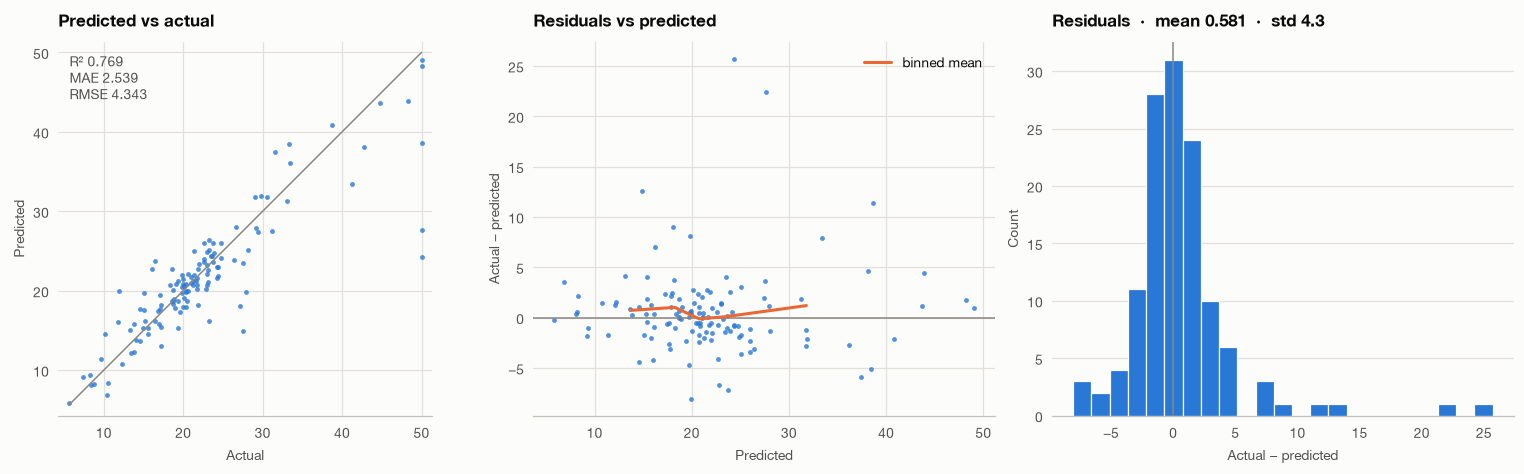

In [ ]:
plotting.plot_regression_diagnostics(y_test, regressor.predict(x_test))

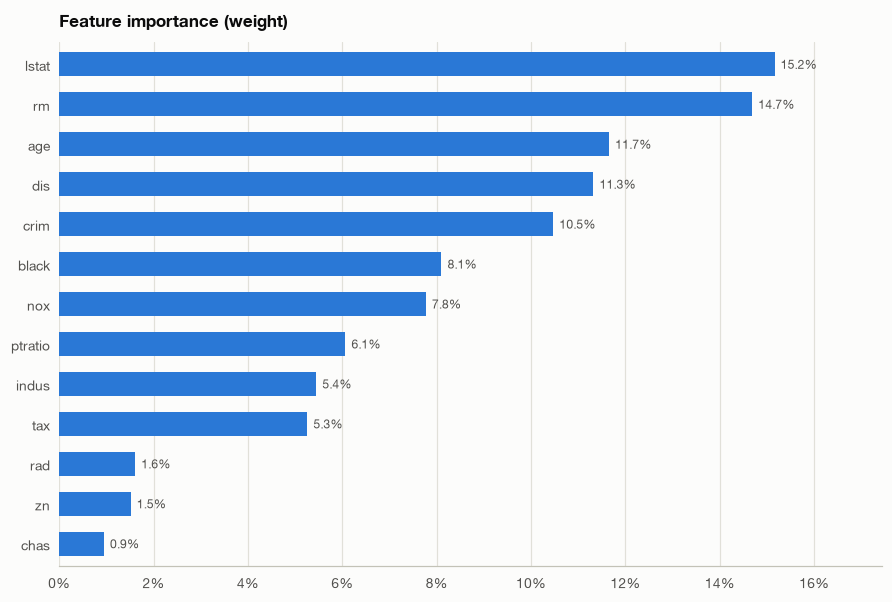

In [ ]:
plotting.plot_feature_importance(regressor, importance_type="weight")

Learning curves need a model fit with an `eval_set`; the `fit_xgb_*` final models are fit without one, so here's a plain model with early stopping.

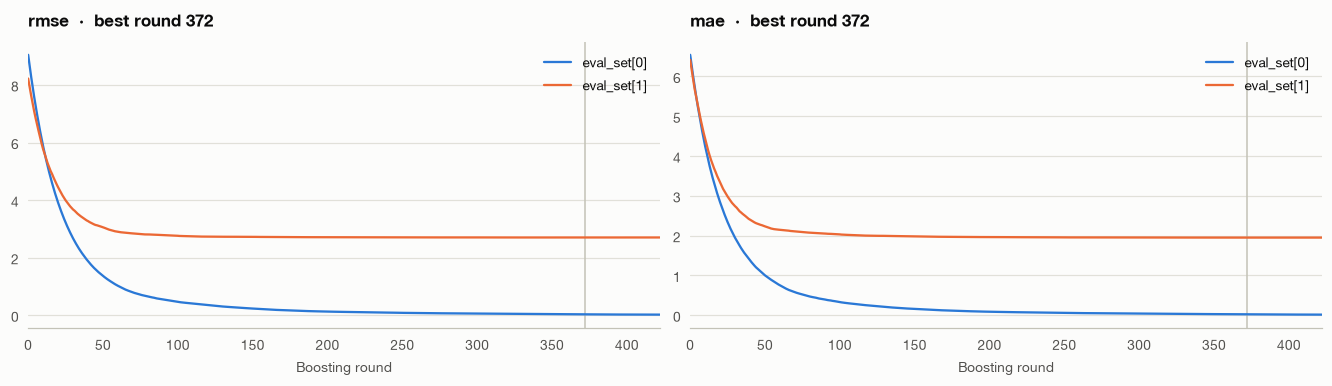

In [ ]:
x_fit, x_val, y_fit, y_val = train_test_split(
    x_train, y_train, test_size=0.25, random_state=0
)
curves_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    early_stopping_rounds=50,
    eval_metric=["rmse", "mae"],
).fit(x_fit, y_fit, eval_set=[(x_fit, y_fit), (x_val, y_val)], verbose=False)
plotting.plot_learning_curves(curves_model)

Forecast: a small lag model on the energy data, tested on the second half of July 2018. Lines break where data is missing.

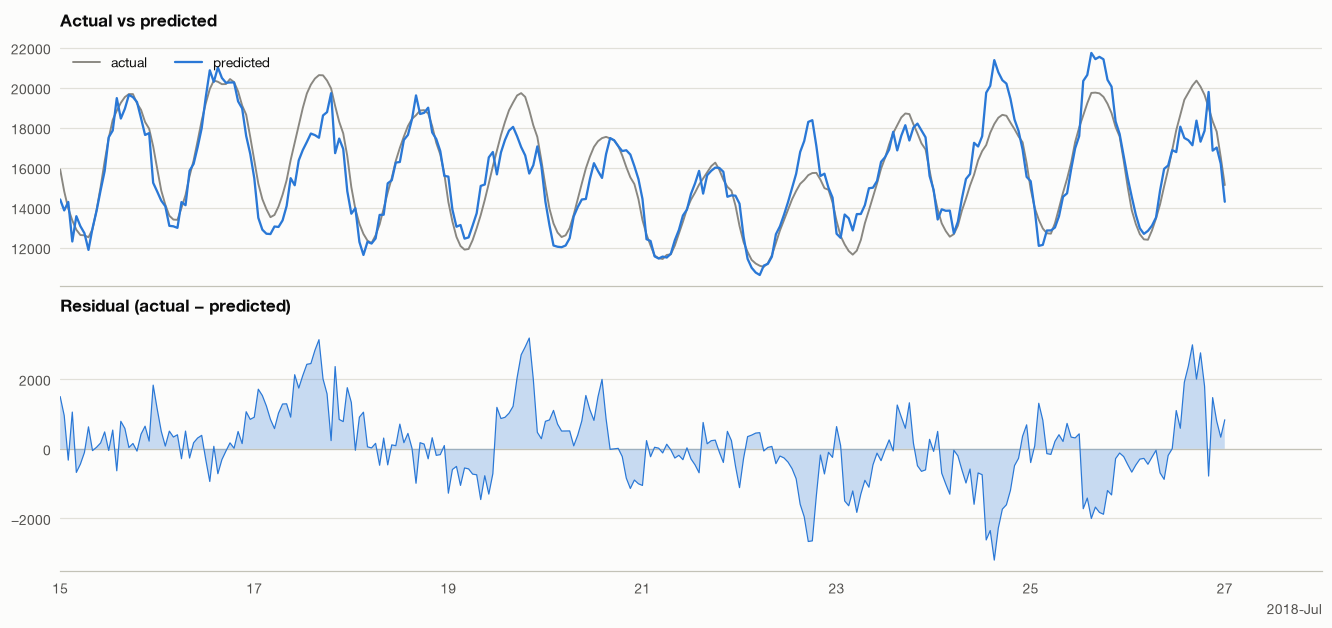

In [ ]:
features = (
    energy.filter(pl.col("ts") >= datetime(2018, 1, 1))
    .with_columns(
        lag24=pl.col("val").shift(24),
        lag168=pl.col("val").shift(168),
        hour=pl.col("ts").dt.hour(),
        weekday=pl.col("ts").dt.weekday(),
    )
    .drop_nulls()
)
cols = ["lag24", "lag168", "hour", "weekday"]
train = features.filter(pl.col("ts") < datetime(2018, 7, 15))
test = features.filter(pl.col("ts") >= datetime(2018, 7, 15))
forecaster = xgb.XGBRegressor(n_estimators=300, max_depth=5).fit(
    train.select(cols), train["val"]
)
plotting.plot_forecast(test["val"], forecaster.predict(test.select(cols)), test["ts"])

### Classification

Binary: breast cancer (sklearn).

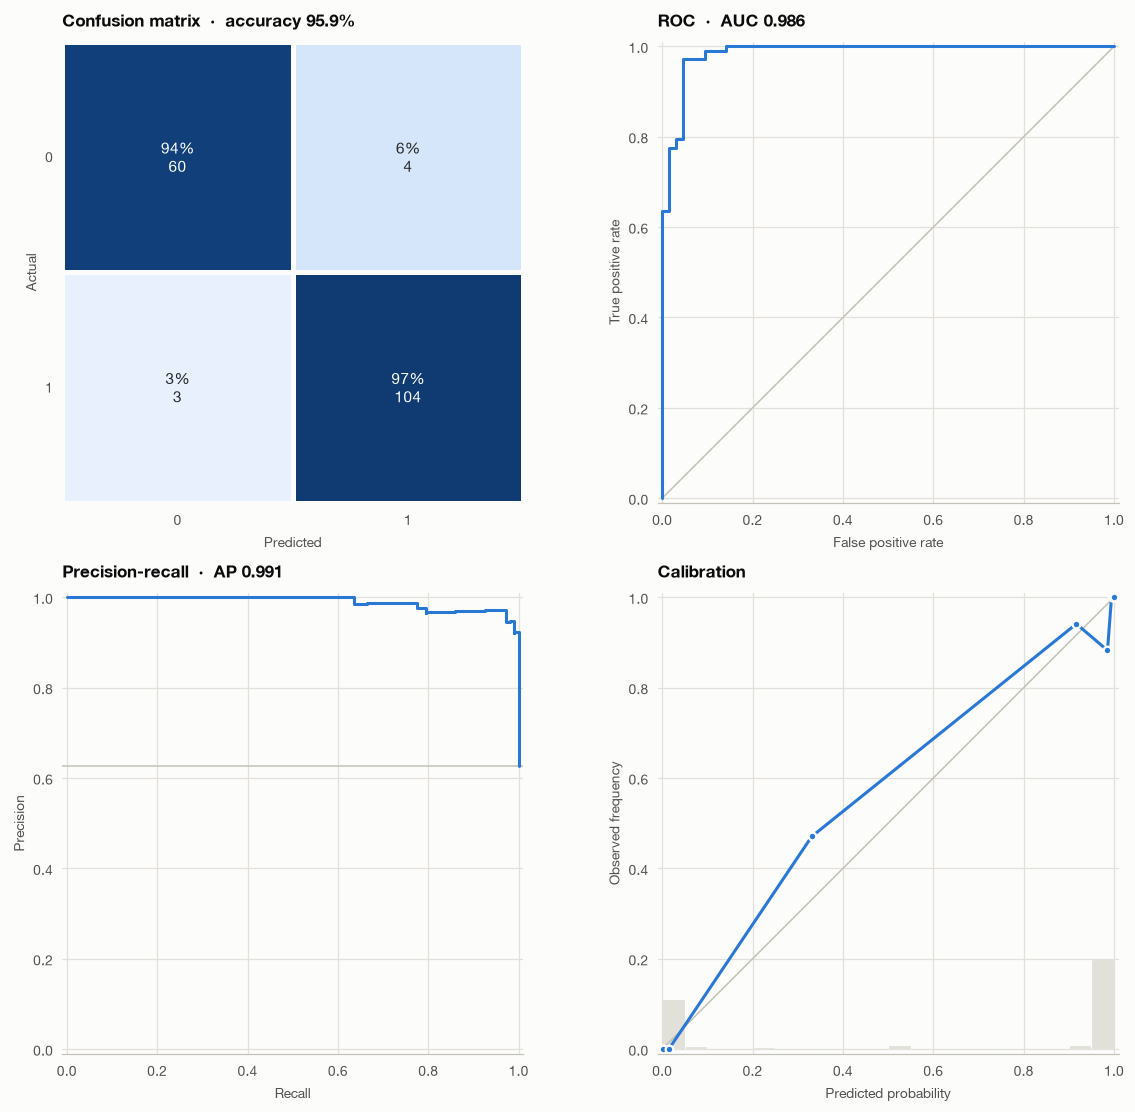

In [ ]:
from sklearn.datasets import load_breast_cancer, load_wine

cancer = load_breast_cancer(as_frame=True)
xb, yb = pl.from_pandas(cancer.data), pl.DataFrame({"y": cancer.target.to_numpy()})
xb_train, xb_test, yb_train, yb_test = train_test_split(
    xb, yb, test_size=0.3, random_state=0, stratify=yb
)
classifier = fit_xgb_classifier(xb_train, yb_train, xb_test, yb_test, n_trials=10).model
plotting.plot_classification_diagnostics(yb_test, classifier.predict_proba(xb_test))

Each panel also exists on its own, with `ax=`; e.g. raw counts instead of row shares:

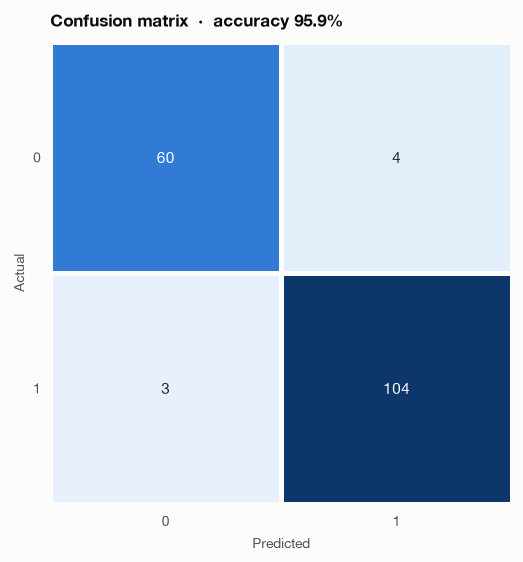

In [ ]:
plotting.plot_confusion_matrix(yb_test, classifier.predict(xb_test), normalize=False)

Multiclass: wine, 3 classes, one curve per class (one vs rest). Labels mapped to names first, so the plots show them.

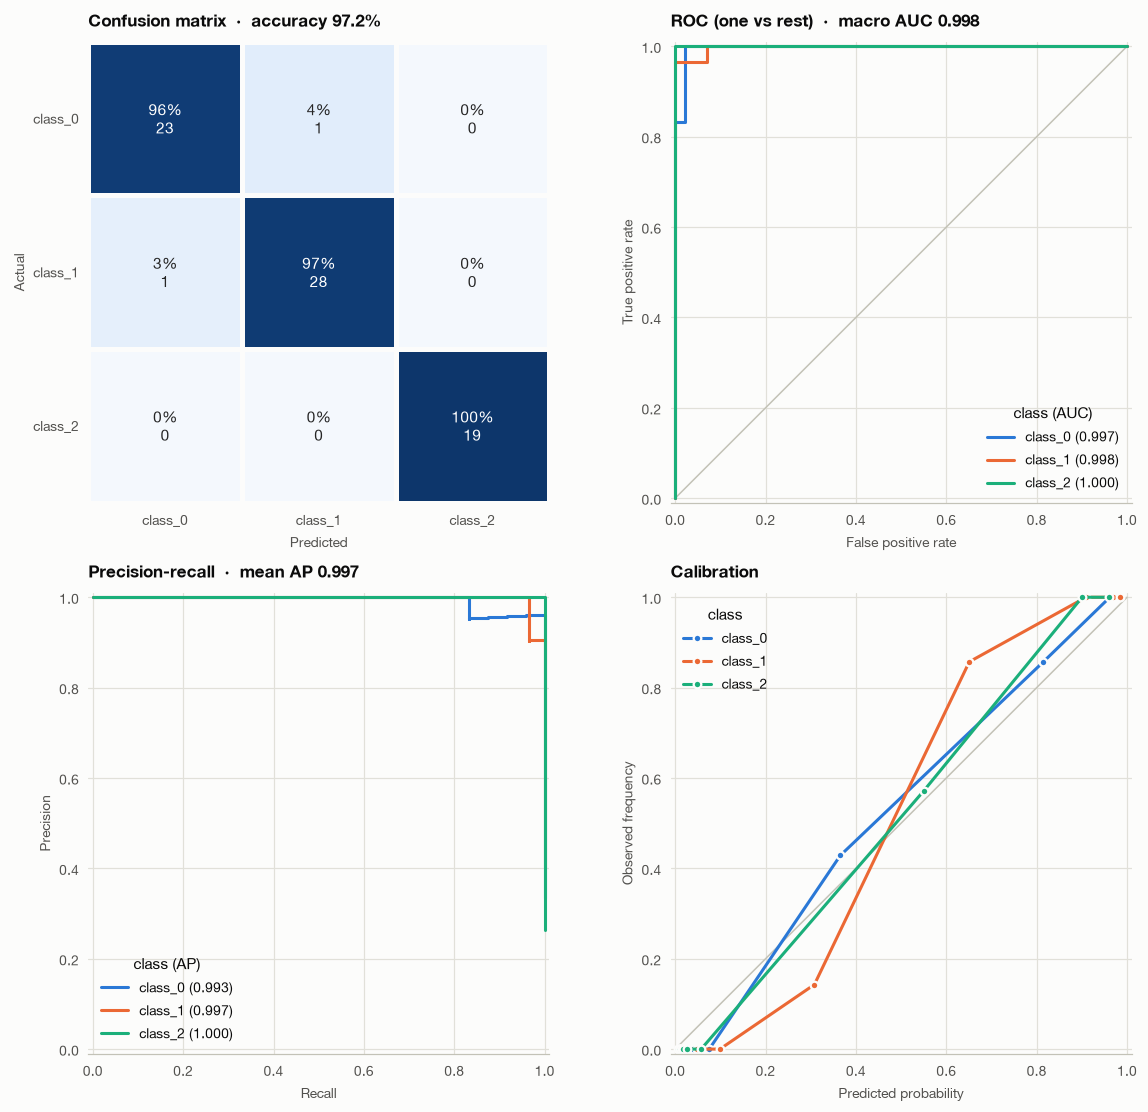

In [ ]:
wine = load_wine(as_frame=True)
xw = pl.from_pandas(wine.data)
yw = pl.DataFrame({"y": wine.target.to_numpy()})
xw_train, xw_test, yw_train, yw_test = train_test_split(
    xw, yw, test_size=0.4, random_state=0, stratify=yw
)
wine_classifier = fit_xgb_classifier(
    xw_train, yw_train, xw_test, yw_test, n_trials=10
).model
names = yw_test.select(pl.col("y").replace_strict(dict(enumerate(wine.target_names))))
plotting.plot_classification_diagnostics(names, wine_classifier.predict_proba(xw_test))

## Plotters

The same plots, bundled around one thing being analysed. The constructor takes what stays the same across plots (data, columns, labels, model); the methods take what varies per plot (bins, scales, grouping, `ax`, ...). Every method returns its figure.

In [ ]:
from lzipp_ml_lib.analysis.plotting import (
    ClassifierPlotter,
    EDAPlotter,
    ModelPlotter,
    RegressionPlotter,
    TimeSeriesPlotter,
)

### `EDAPlotter`

One table. `columns` and `sample` apply to every plot; `as_categorical` makes `category_counts` treat the numeric `rad` codes as categories.

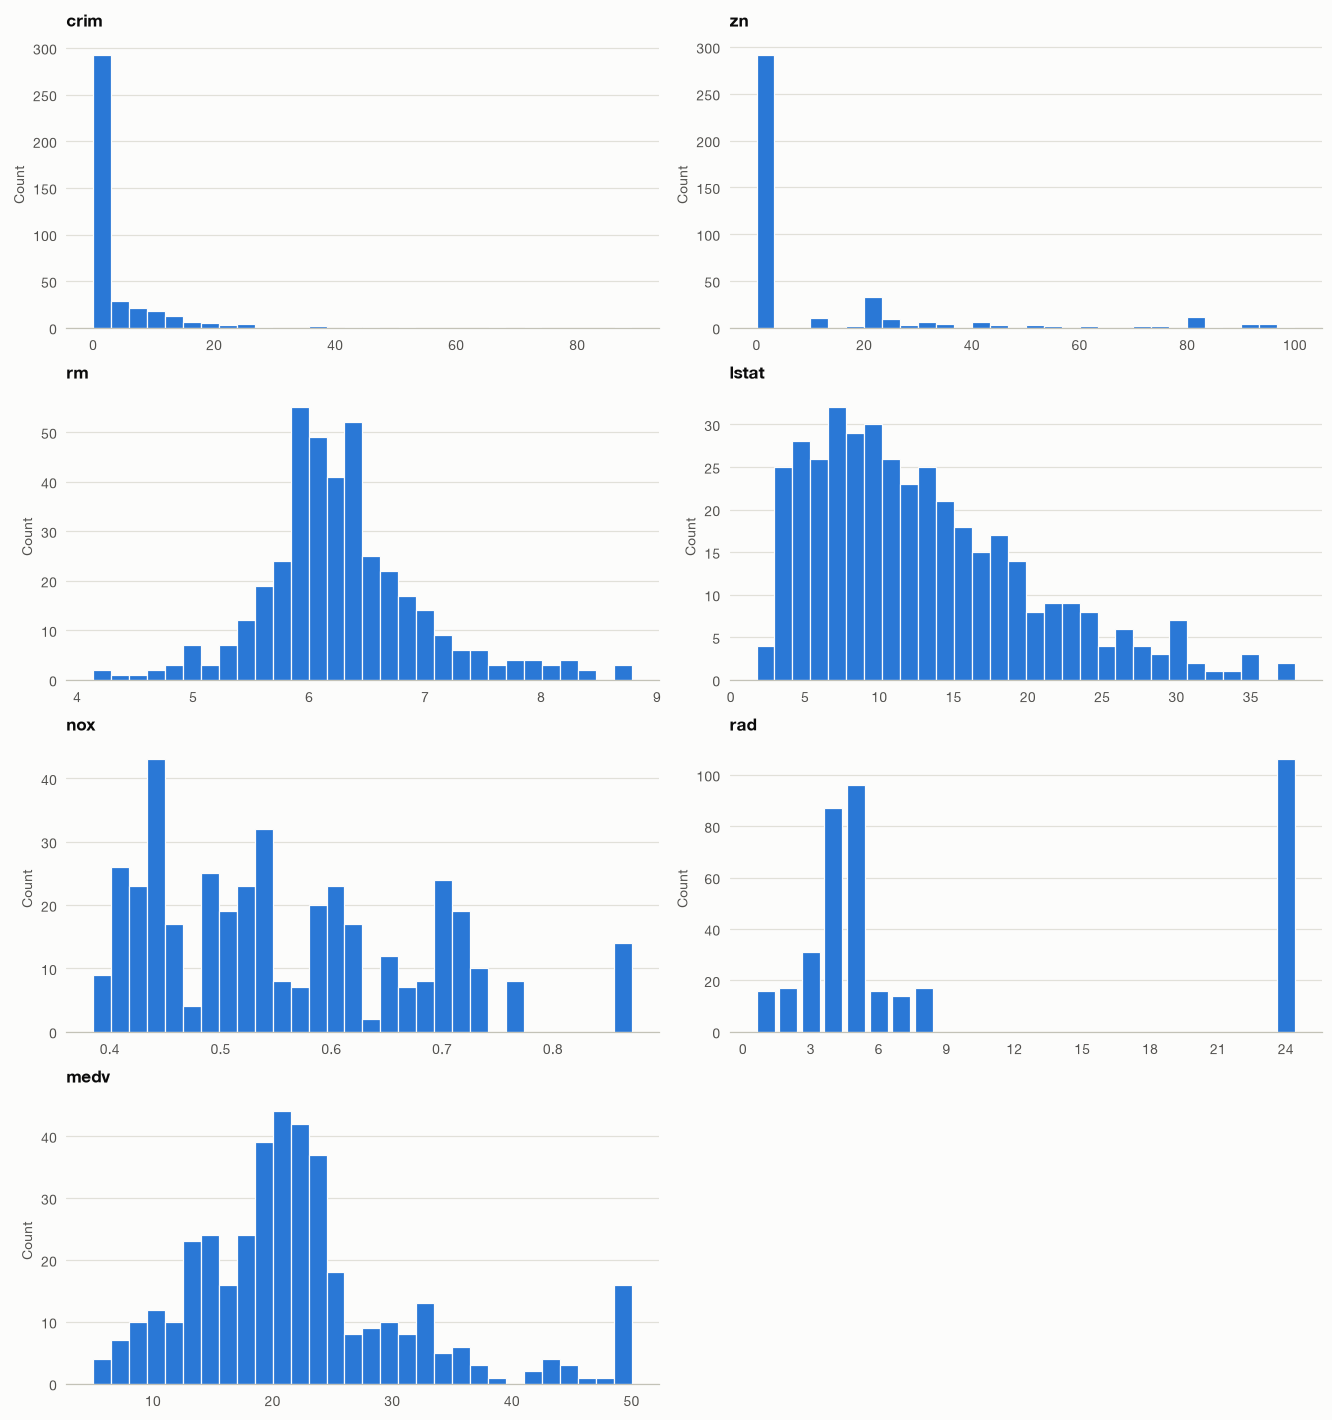

In [ ]:
eda = EDAPlotter(
    housing,
    ["crim", "zn", "rm", "lstat", "nox", "rad", "medv", "river"],
    sample=400,
    as_categorical=["rad"],
)
eda.histograms(bins=30)

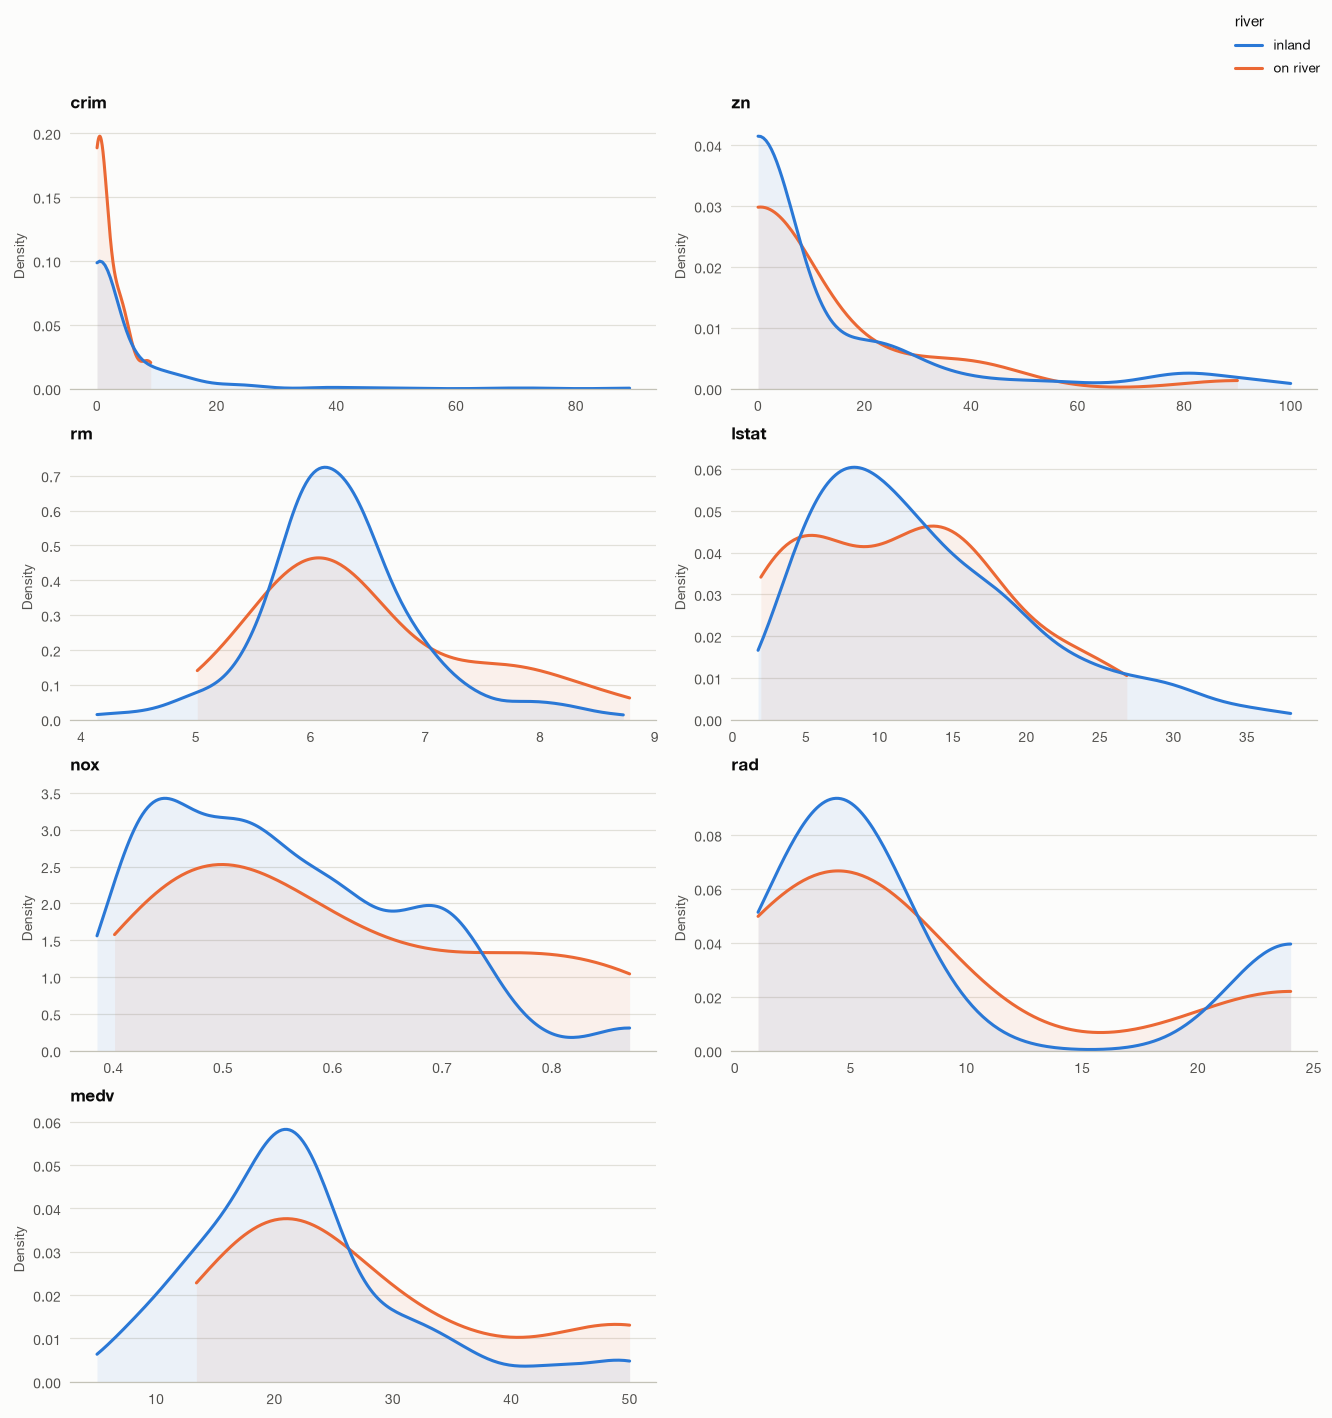

In [ ]:
eda.kde(by="river")

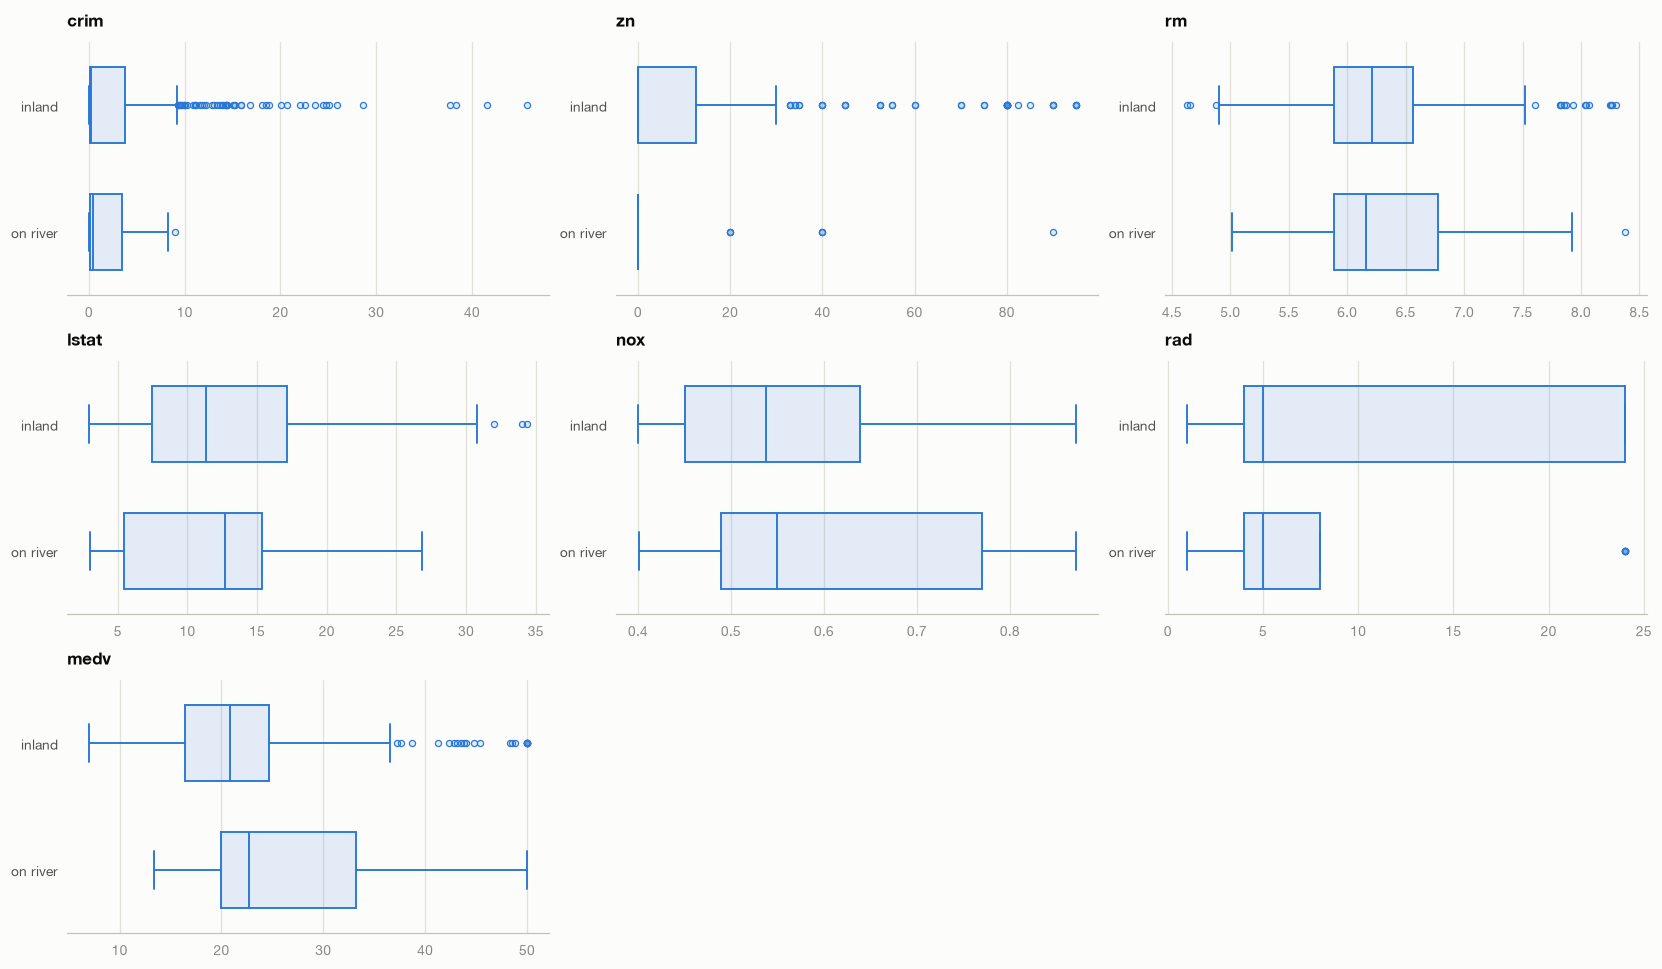

In [ ]:
eda.boxplots(by="river", clip=(0.01, 0.99))

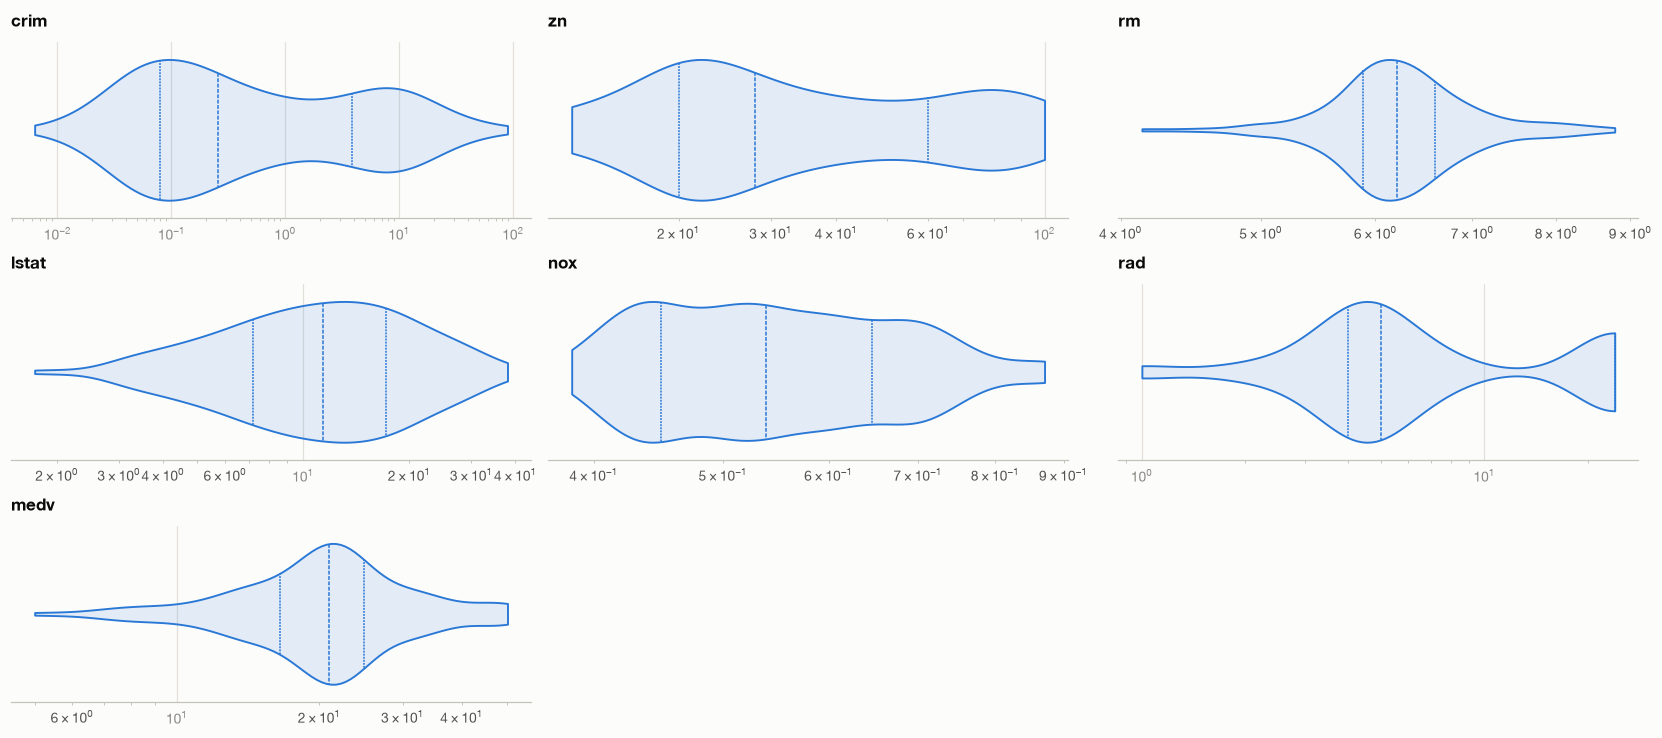

In [ ]:
eda.violinplots(log=True)

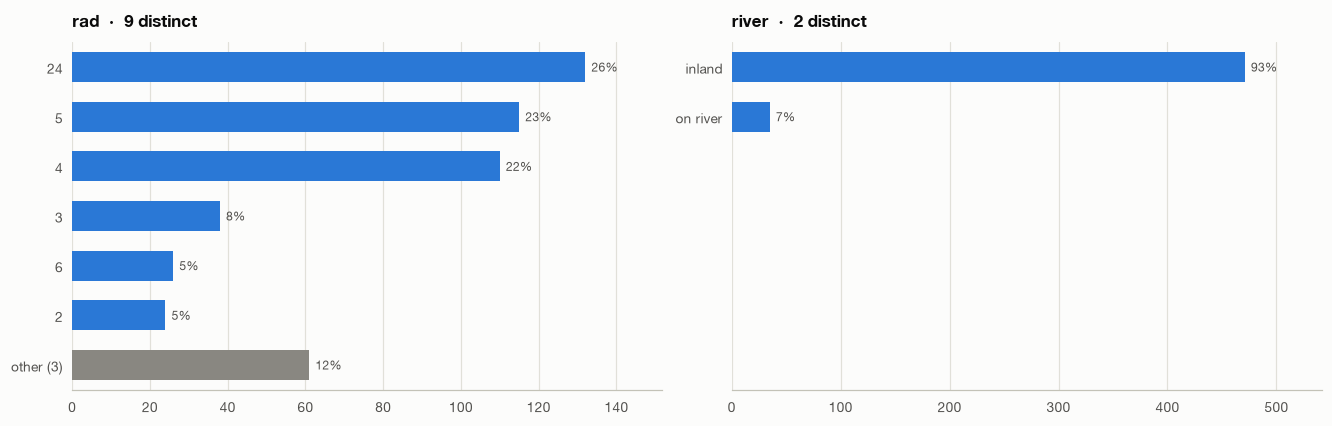

In [ ]:
eda.category_counts(top_k=6)

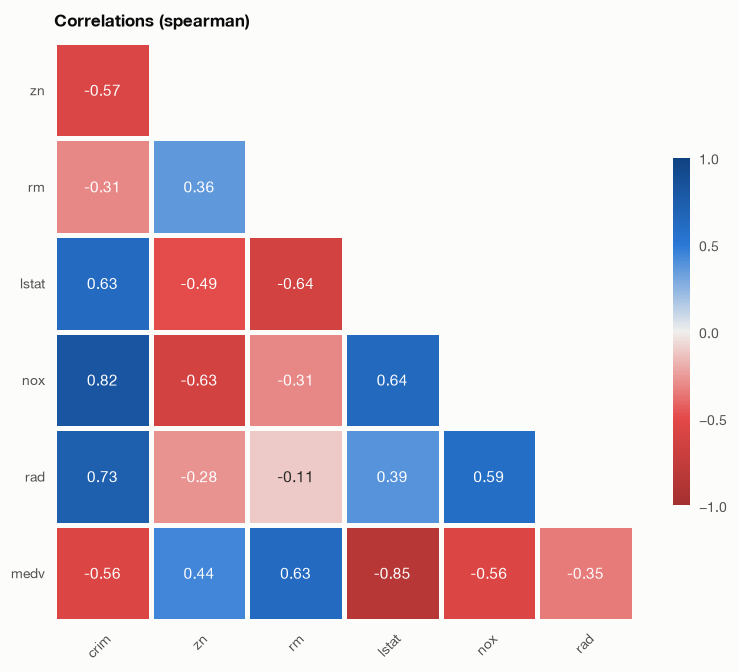

In [ ]:
eda.corr_heatmap(method="spearman", figsize=(8, 6))

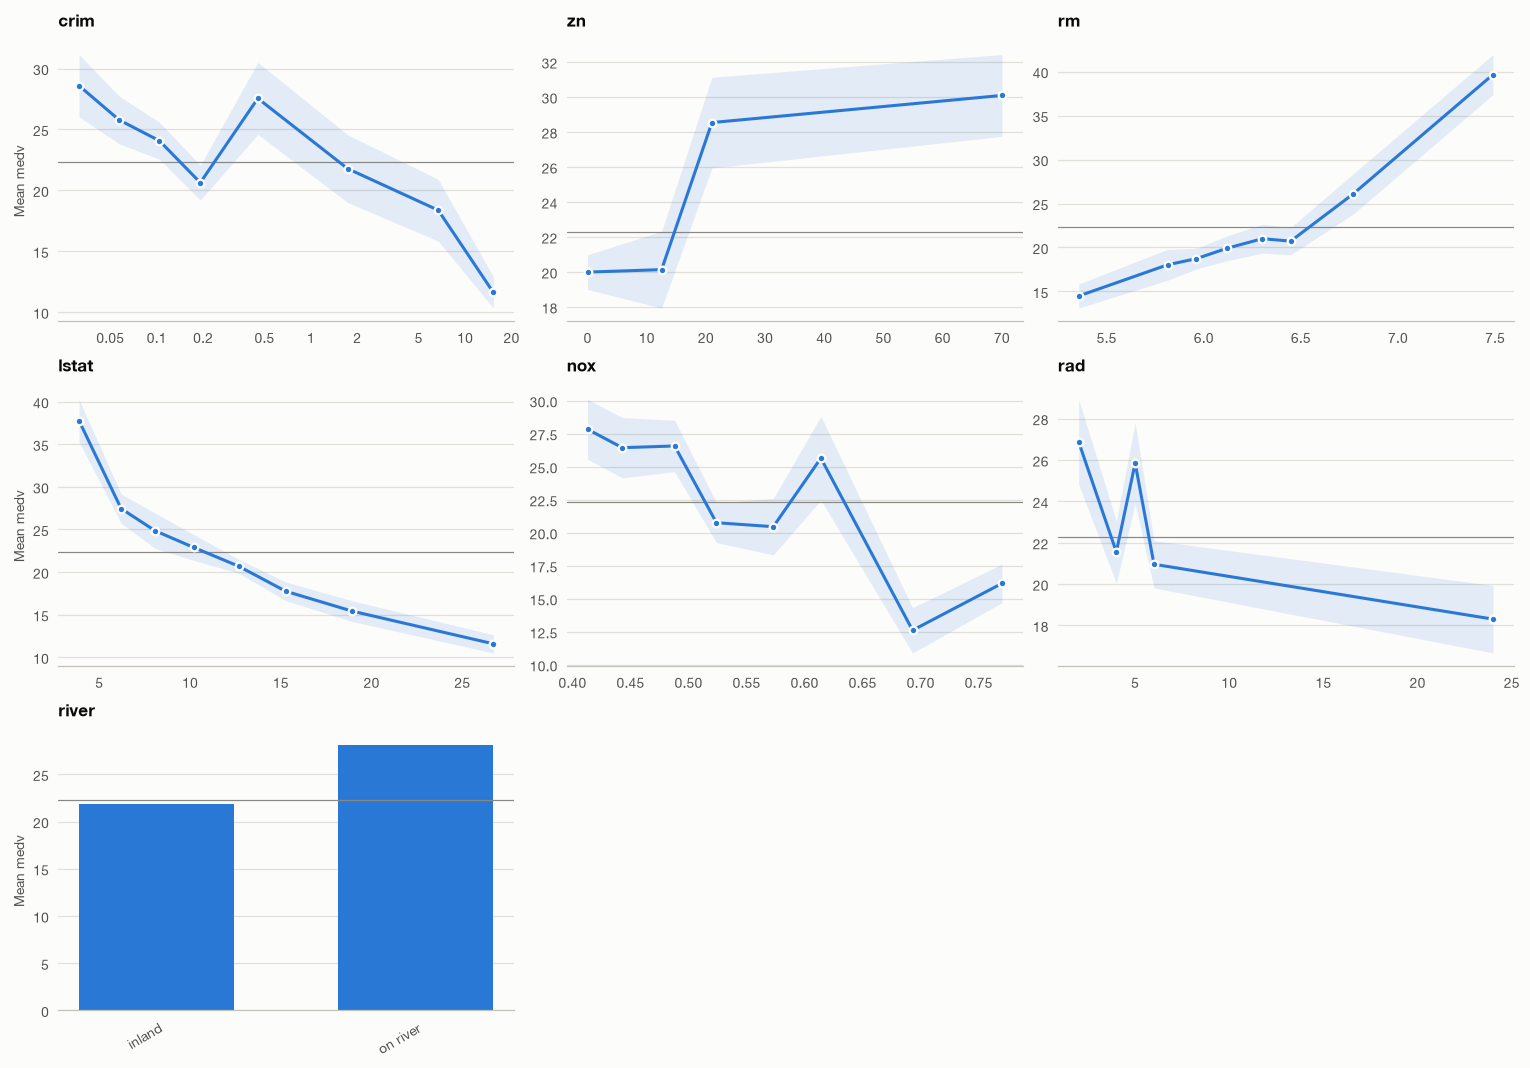

In [ ]:
eda.feature_target("medv", n_bins=8, log_x=["crim"])

Missing values need a table that has some: the BTC data.

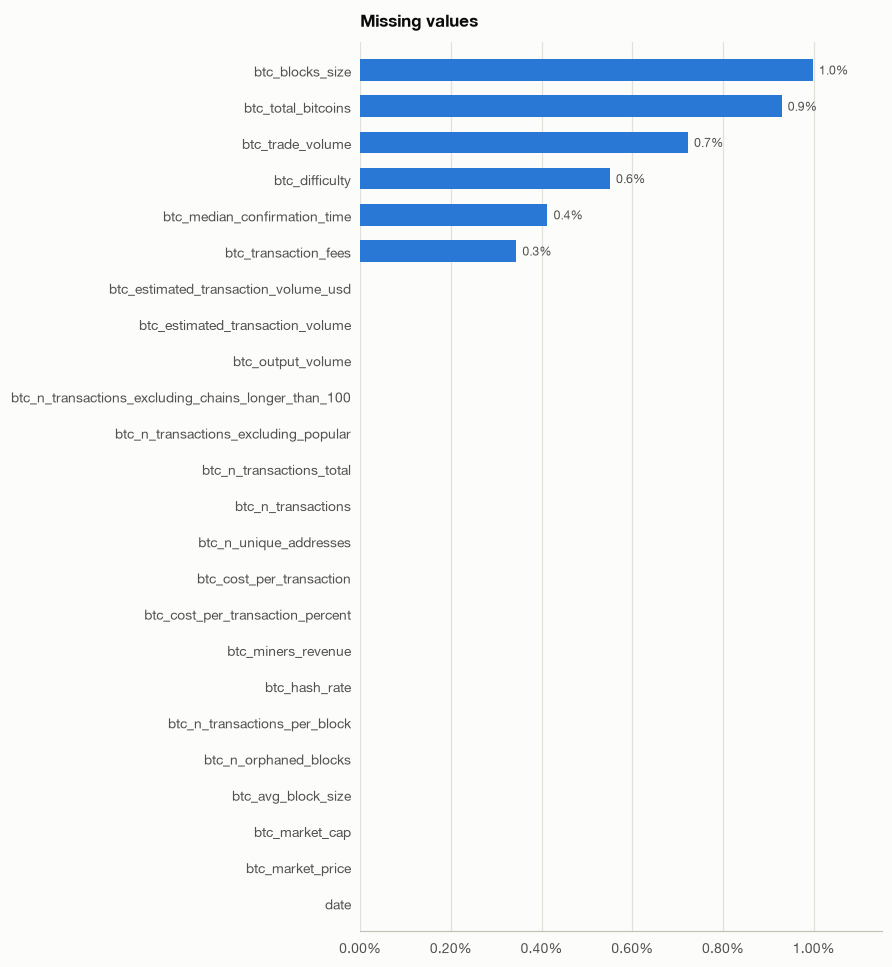

In [ ]:
EDAPlotter(df).missing_values()

### `TimeSeriesPlotter`

One series: `target_col` (default `"val"`) over `time_col` (default `"ts"`), sorted by time before every plot. `columns` only applies to `grid`.

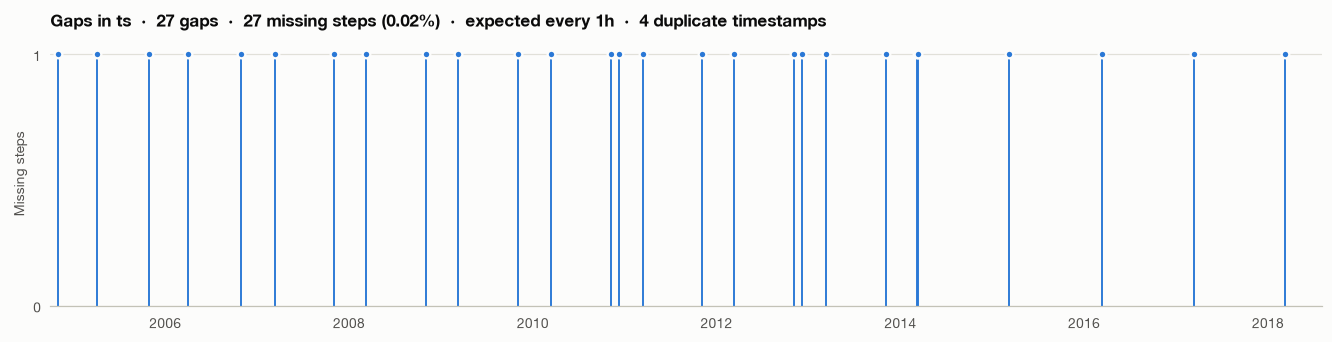

In [ ]:
energy_series = TimeSeriesPlotter(energy)
energy_series.gaps()

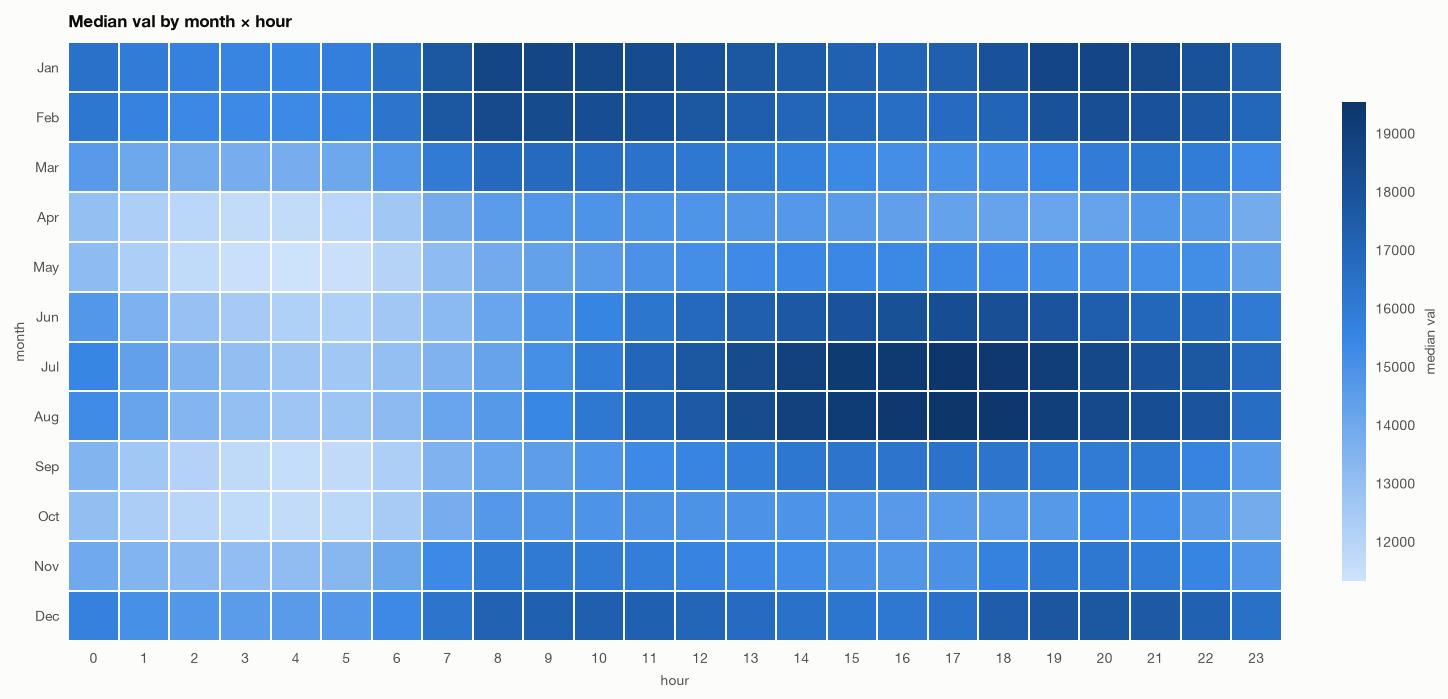

In [ ]:
energy_series.seasonal_profile(rows="month", cols="hour", agg="median")

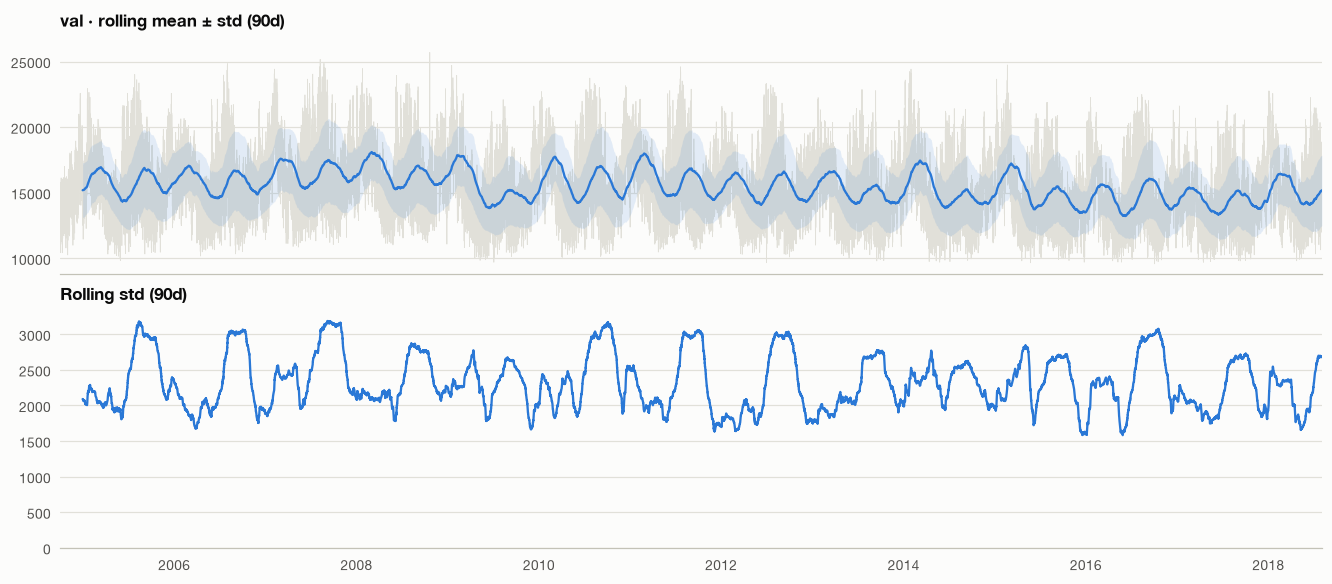

In [ ]:
energy_series.rolling_stats(window="90d")

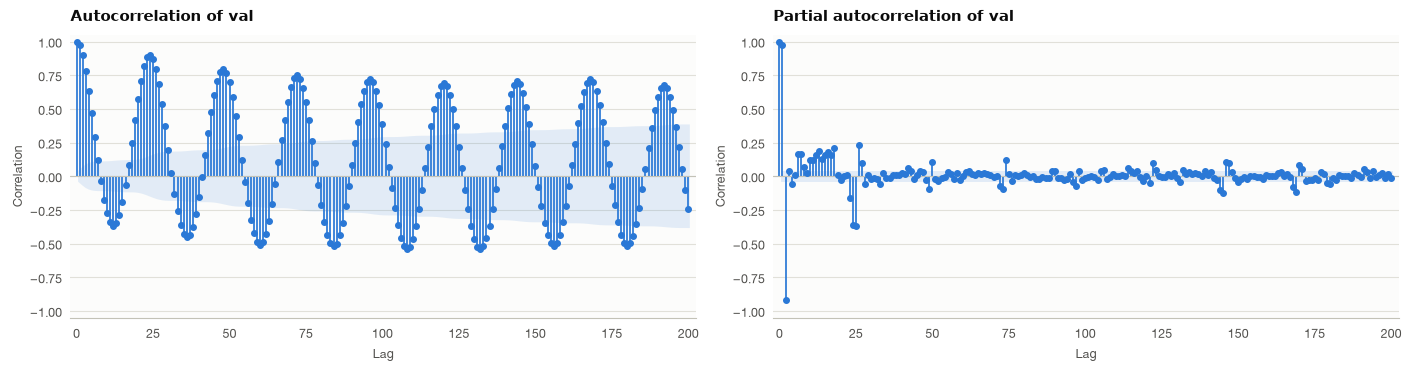

In [ ]:
recent_series = TimeSeriesPlotter(recent)
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 3.6), layout="constrained")
recent_series.autocorrelation(lags=200, ax=left)
recent_series.partial_autocorrelation(lags=200, ax=right)

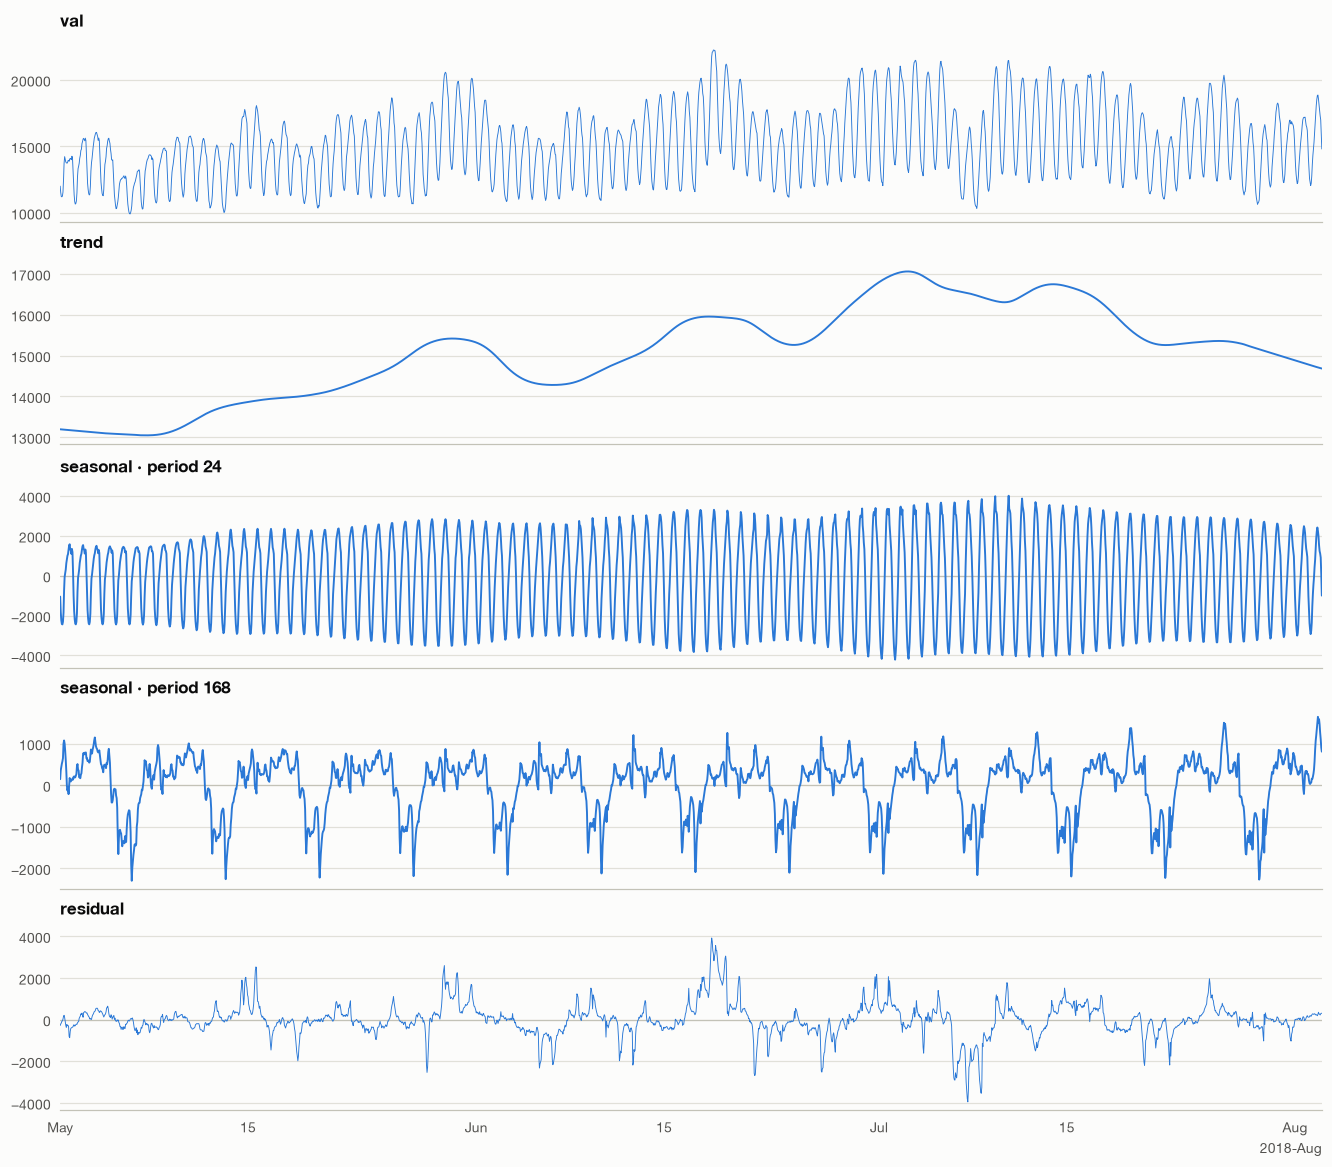

In [ ]:
recent_series.decomposition(periods=(24, 168))

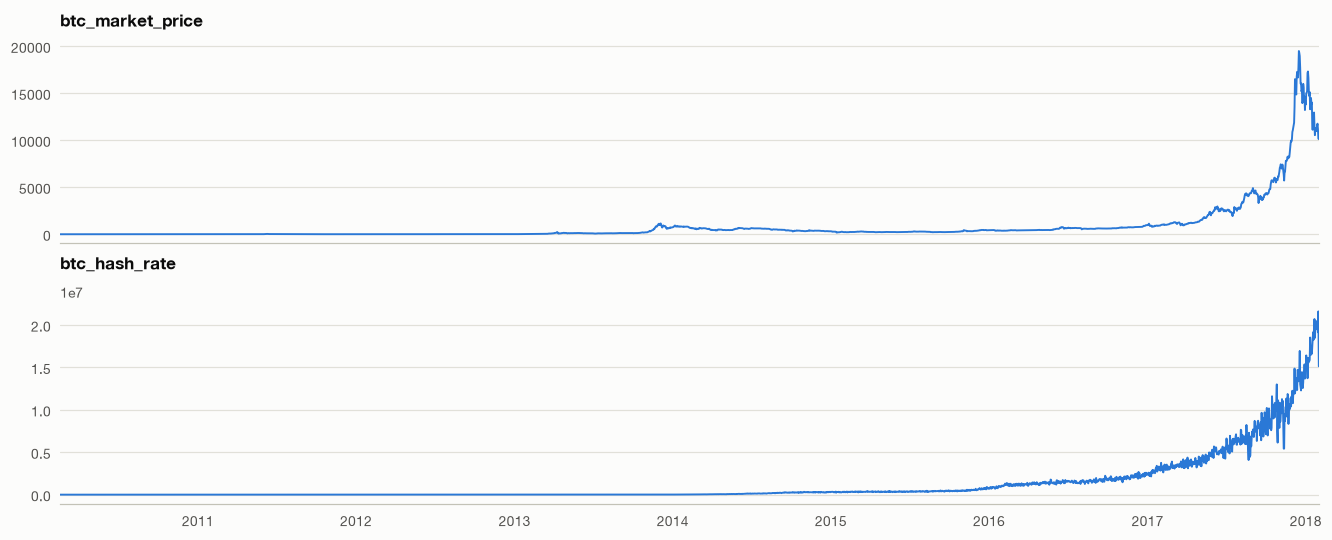

In [ ]:
btc_series = TimeSeriesPlotter(
    df, "date", "btc_market_price", columns=["btc_market_price", "btc_hash_rate"]
)
btc_series.grid()

### `RegressionPlotter`

One set of regression results; `ts` (optional) puts the forecast on a time axis.

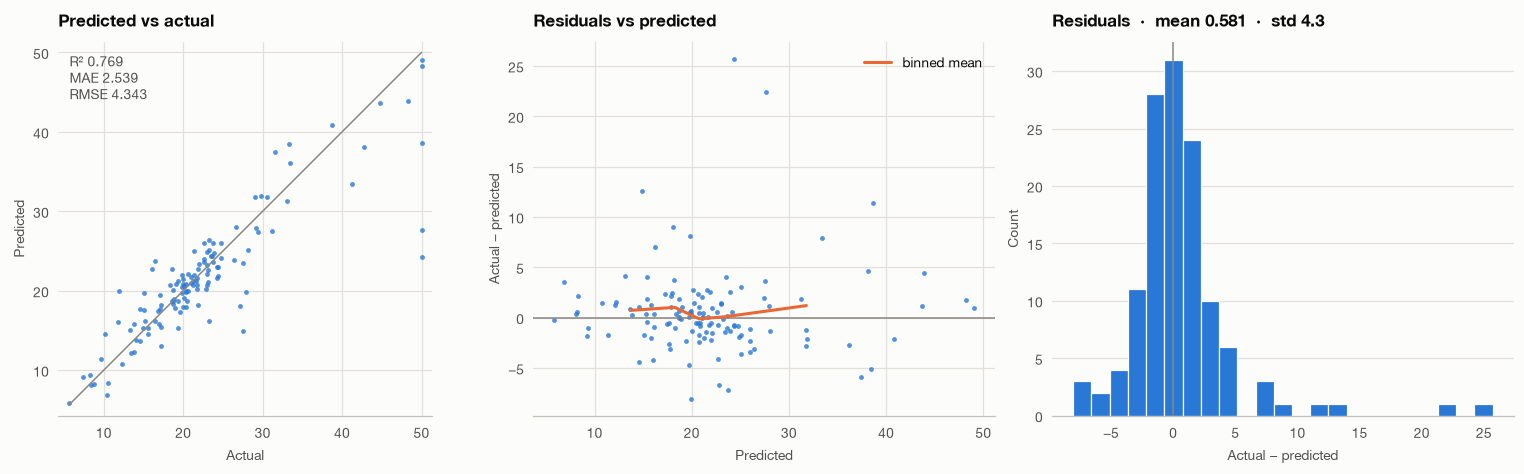

In [ ]:
housing_results = RegressionPlotter(y_test, regressor.predict(x_test))
housing_results.diagnostics()

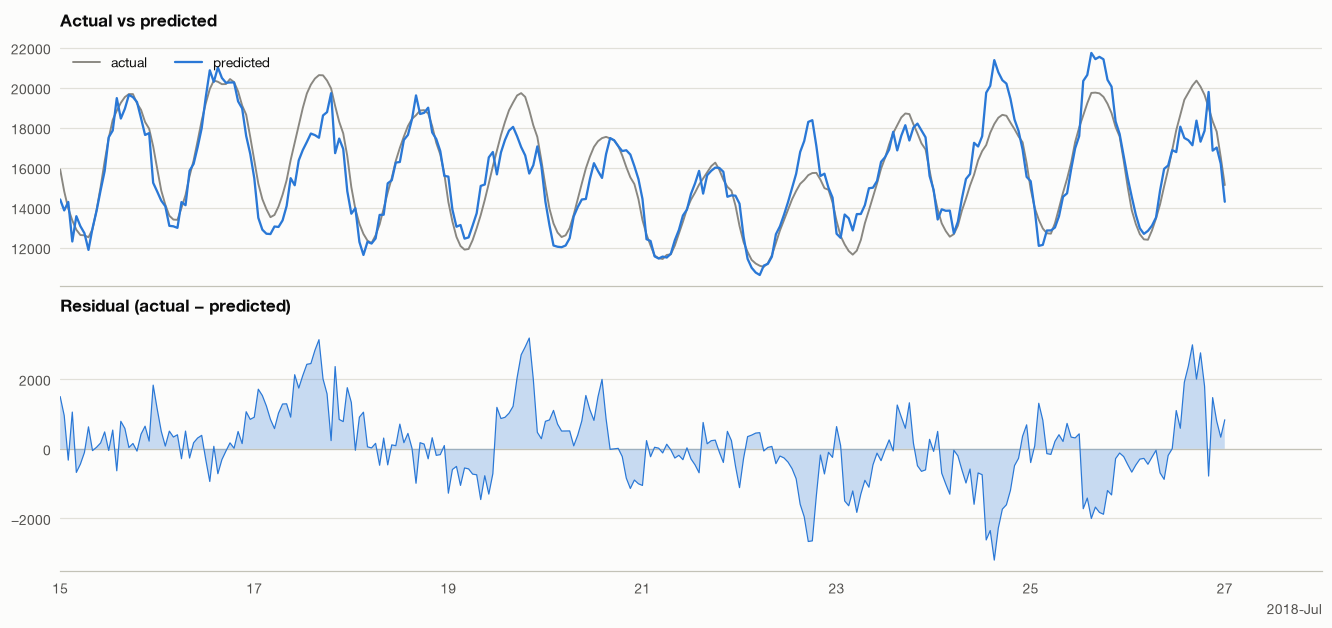

In [ ]:
energy_results = RegressionPlotter(
    test["val"], forecaster.predict(test.select(cols)), ts=test["ts"]
)
energy_results.forecast()

### `ClassifierPlotter`

One set of classification results: `y_pred` (labels), `y_proba` (probabilities) or both. Without `y_pred`, the confusion matrix uses the most probable class.

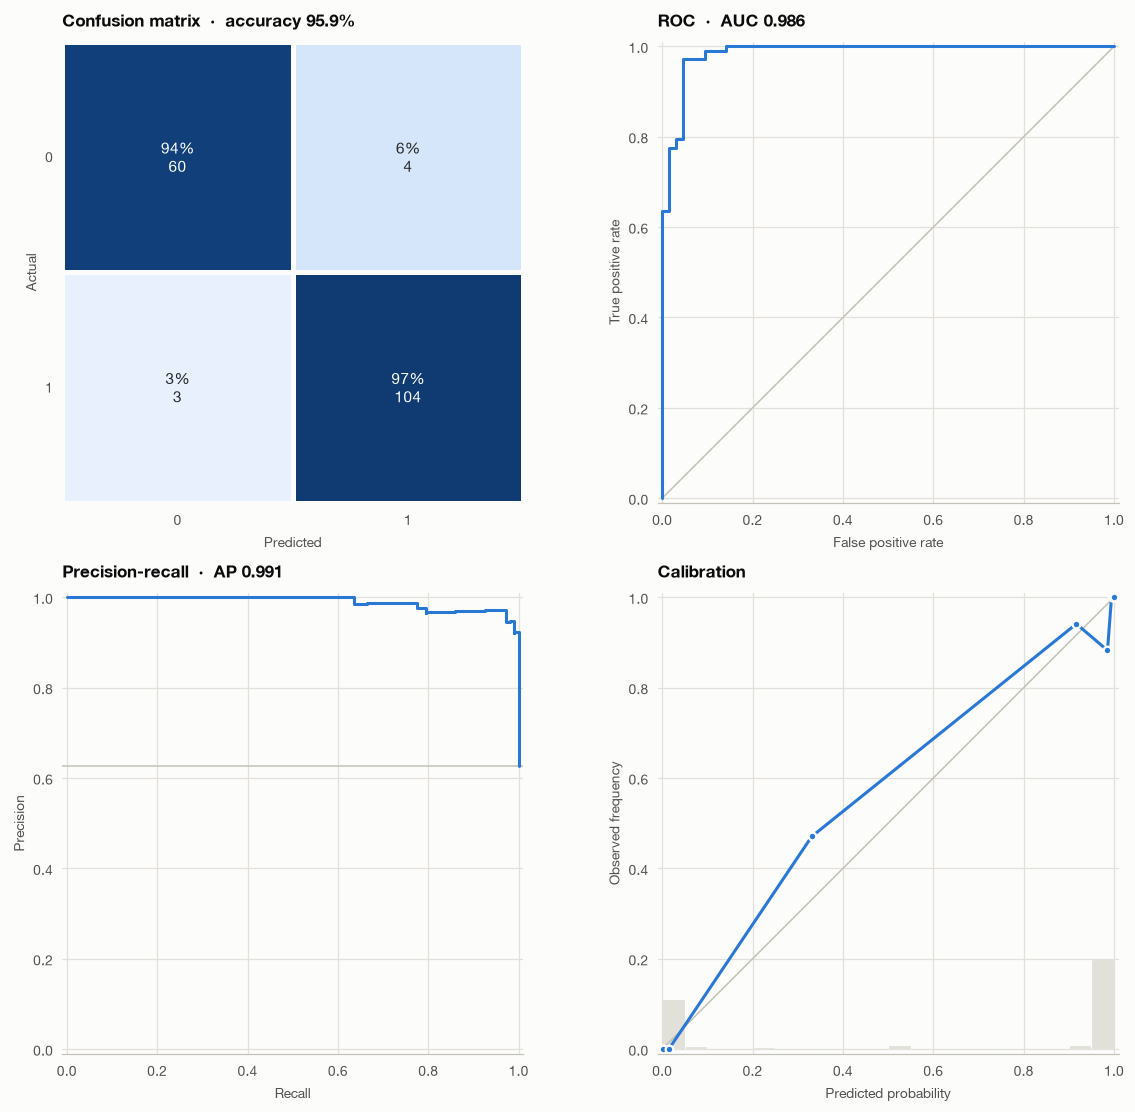

In [ ]:
cancer_results = ClassifierPlotter(yb_test, y_proba=classifier.predict_proba(xb_test))
cancer_results.diagnostics()

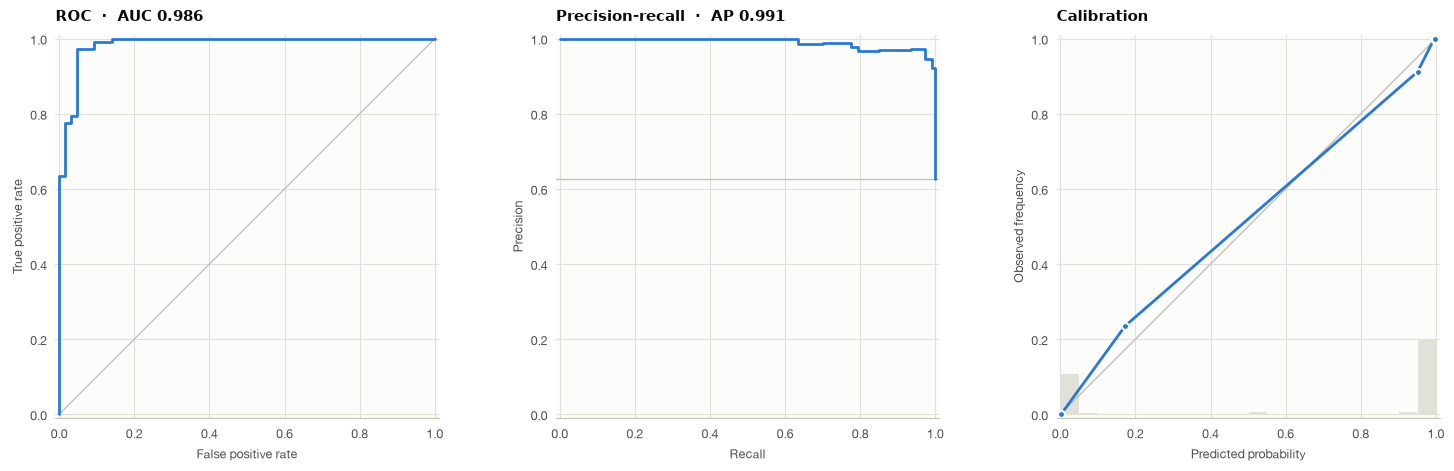

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), layout="constrained")
cancer_results.roc_curves(ax=axes[0])
cancer_results.precision_recall(ax=axes[1])
cancer_results.calibration(n_bins=5, ax=axes[2])

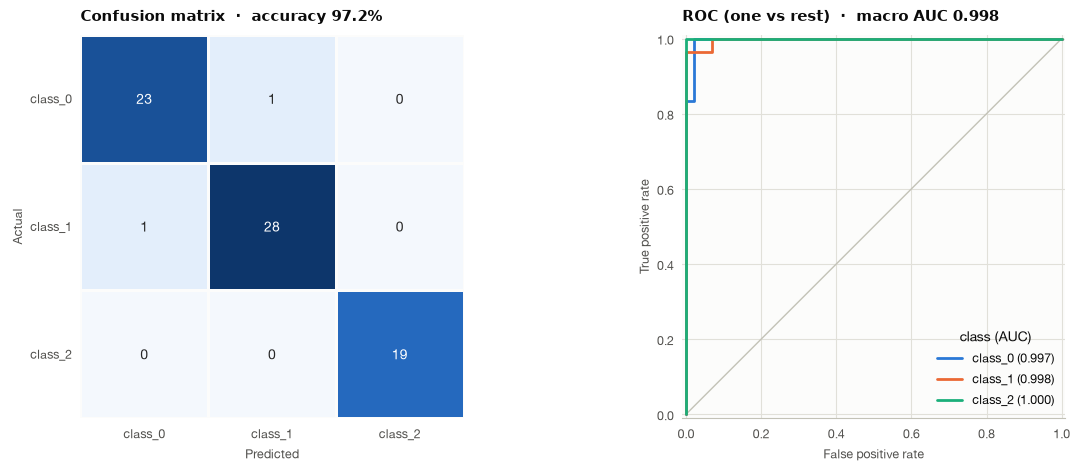

In [ ]:
predicted_names = wine.target_names[wine_classifier.predict(xw_test)]
wine_results = ClassifierPlotter(
    names, y_pred=predicted_names, y_proba=wine_classifier.predict_proba(xw_test)
)
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.6), layout="constrained")
wine_results.confusion_matrix(normalize=False, ax=left)  # from y_pred
wine_results.roc_curves(ax=right)  # from y_proba, one curve per class

### `ModelPlotter`

One fitted XGBoost model. Learning curves need a model fit with an `eval_set`.

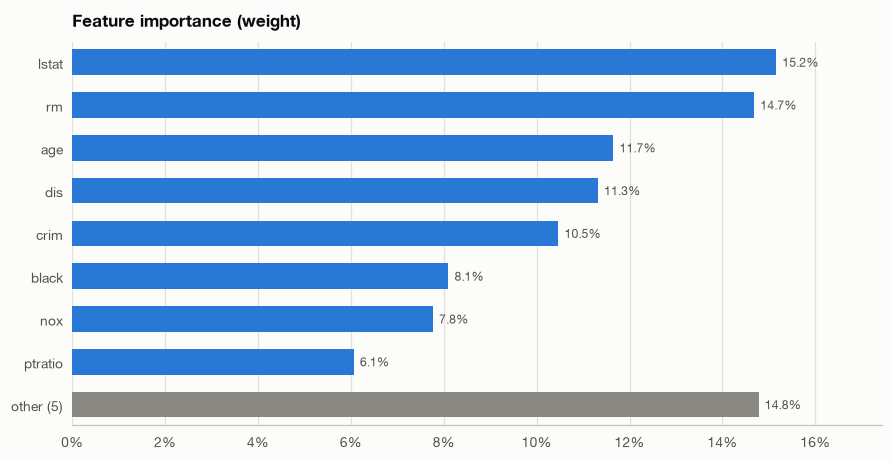

In [ ]:
ModelPlotter(regressor).feature_importance(importance_type="weight", top_k=8)

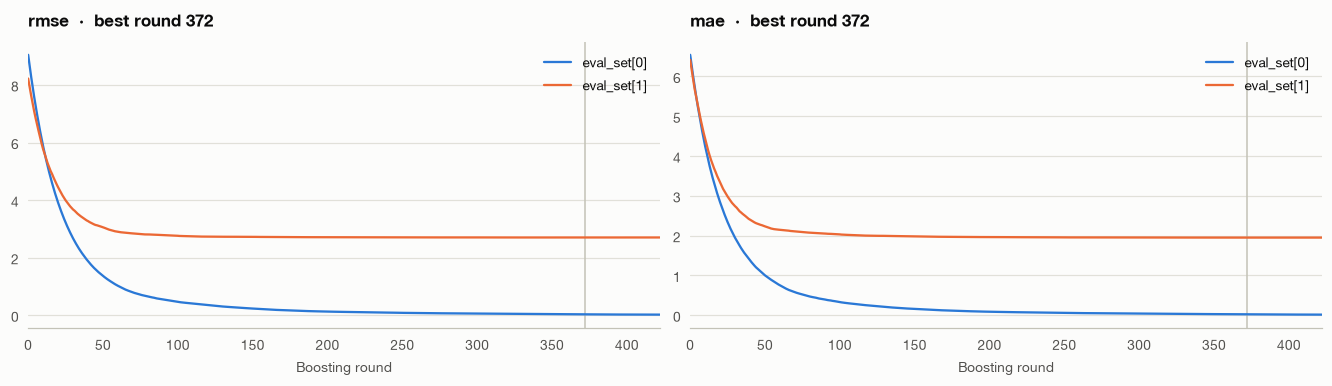

In [ ]:
ModelPlotter(curves_model).learning_curves()